# 🏦 Bank Term Deposit Campaign Effectiveness Analytics
## Phase 3 — Exploratory Data Analysis & Statistical Insights

| Field | Detail |
|---|---|
| **Project Code** | BCA-2025-001 |
| **Engagement** | Campaign Intelligence & Customer Targeting |
| **Client** | BankX (Retail Banking Division) |
| **Analyst** | Ritik |
| **Dataset** | UCI Bank Marketing · `bank-full.csv` · 45,211 records · 17 features |
| **Stack** | Python 3.x · pandas · matplotlib · seaborn · scipy · numpy |
| **Phase Status** | ✅ Complete |

---

### Analytical Objectives
This notebook answers five questions on behalf of BankX's Head of Retail Banking:

1. **Who is converting?** — Which customer demographics over-index on term deposit subscription
2. **When are we winning?** — Which months, days, and contact frequencies produce best results
3. **What makes a warm lead?** — How prior campaign history predicts current conversion
4. **Where is budget wasted?** — Campaign fatigue, over-contacting, wrong segments
5. **How confident are we?** — Statistical validation of all key findings

---

### Notebook Structure

| Section | Content | Charts |
|---|---|---|
| 1 | Data Loading & Feature Engineering | — |
| 2 | Dataset Overview & Summary Statistics | — |
| 3 | Target Variable & Class Imbalance | Chart 01 |
| 4 | Univariate: Numeric Features | Chart 02 |
| 5 | Univariate: Categorical Features | Chart 03 |
| 6 | Bivariate: Conversion by Job | Chart 04 |
| 7 | Bivariate: Conversion by Age Band | Chart 05 |
| 8 | Bivariate: Warm Lead Multiplier | Chart 06 |
| 9 | Bivariate: Monthly Volume vs Conversion | Chart 07 |
| 10 | Bivariate: Campaign Fatigue Curve | Chart 08 |
| 11 | Bivariate: Debt Burden Impact | Chart 09 |
| 12 | Bivariate: Balance Tier Conversion | Chart 10 |
| 13 | Call Duration Deep-Dive + Stats Test | Chart 11 |
| 14 | Correlation Matrix | Chart 12 |
| 15 | Statistical Hypothesis Testing | Chart 13 |
| 16 | Multi-Dimensional: Job × Month Heatmap | Chart 14 |
| 17 | Multi-Dimensional: Customer Personas | Chart 15 |
| 18 | EDA Key Findings Summary | — |


---
## Section 1 — Data Loading & Feature Engineering

In [2]:
# ── Dependencies ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Project colour palette (matches Power BI dashboard theme) ─────────────────
BRAND_GREEN  = '#1D9E75'   # Primary positive / above average
BRAND_RED    = '#E24B4A'   # Negative / below average / warning
BRAND_BLUE   = '#378ADD'   # Volume / neutral reference
BRAND_PURPLE = '#7F77DD'   # Secondary accent
BRAND_AMBER  = '#EF9F27'   # Mid-tier / caution
NEUTRAL_DARK = '#2C2C2C'   # Text
NEUTRAL_MID  = '#6B6B6B'   # Subtext / axis labels
BG_LIGHT     = '#F7F7F5'   # Chart backgrounds

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : BG_LIGHT,
    'axes.grid'         : True,
    'grid.color'        : '#E0E0E0',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.spines.bottom': False,
    'font.family'       : 'DejaVu Sans',
    'axes.labelcolor'   : NEUTRAL_DARK,
    'xtick.color'       : NEUTRAL_MID,
    'ytick.color'       : NEUTRAL_MID,
    'axes.titleweight'  : 'bold',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
})

print("✅ Libraries loaded | Style configured")
print(f"   pandas {pd.__version__} · numpy {np.__version__} · seaborn {sns.__version__}")

✅ Libraries loaded | Style configured
   pandas 3.0.3 · numpy 2.5.0 · seaborn 0.13.2


In [3]:
# ── Load dataset ─────────────────────────────────────────────────────────────
# Place bank-full.csv in the same folder as this notebook, or update the path.
df = pd.read_csv('bank-full.csv', sep=';')

# ── Feature engineering — mirrors SQL Script 01 derived columns exactly ───────
# Any change here must be reflected in the SQL schema for consistency.

df['subscription_flag'] = (df['y'] == 'yes').astype(int)

df['age_band'] = pd.cut(df['age'],
    bins=[17, 30, 40, 50, 60, 95],
    labels=['Young (18-30)', 'Early Career (31-40)', 'Mid Career (41-50)',
            'Pre-Retirement (51-60)', 'Retired (61+)'])

df['balance_tier'] = pd.cut(df['balance'],
    bins=[-8020, 0, 1000, 5000, 20000, 102128],
    labels=['Negative', 'Low (0-999)', 'Medium (1K-5K)',
            'High (5K-20K)', 'Very High (20K+)'])

df['contact_freq_band'] = pd.cut(df['campaign'],
    bins=[0, 1, 3, 5, 63],
    labels=['1 Call', '2-3 Calls', '4-5 Calls', '6+ Calls'])

df['debt_burden'] = df.apply(lambda r:
    'Dual Debt Burden'   if r['housing']=='yes' and r['loan']=='yes'
    else ('Housing Loan Only' if r['housing']=='yes'
    else ('Personal Loan Only' if r['loan']=='yes'
    else  'Debt Free')), axis=1)

df['prior_contact_flag'] = df['pdays'].apply(
    lambda x: 'Cold Lead' if x == -1 else 'Warm Lead')

df['call_quality_band'] = pd.cut(df['duration'],
    bins=[-1, 0, 60, 300, 600, 4919],
    labels=['No Connection', 'Very Short (<1 min)',
            'Short (1-5 min)', 'Medium (5-10 min)', 'Long (10+ min)'])

month_num_map   = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
                   'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
month_label_map = {'jan':'Jan','feb':'Feb','mar':'Mar','apr':'Apr',
                   'may':'May','jun':'Jun','jul':'Jul','aug':'Aug',
                   'sep':'Sep','oct':'Oct','nov':'Nov','dec':'Dec'}
df['month_num']   = df['month'].map(month_num_map)
df['month_label'] = df['month'].map(month_label_map)

# ── Verification ──────────────────────────────────────────────────────────────
print("✅ Dataset loaded and features engineered")
print(f"   Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Null values      : {df.isnull().sum().sum()} (confirmed zero)")
print(f"   Subscriptions    : {df['subscription_flag'].sum():,}  ({df['subscription_flag'].mean()*100:.2f}%)")
print(f"   Non-subscriptions: {(df['subscription_flag']==0).sum():,} ({(df['subscription_flag']==0).mean()*100:.2f}%)")
print(f"   Class ratio      : {(df['subscription_flag']==0).sum() / df['subscription_flag'].sum():.1f}:1  (no:yes)")

✅ Dataset loaded and features engineered
   Shape            : 45,211 rows × 26 columns
   Null values      : 0 (confirmed zero)
   Subscriptions    : 5,289  (11.70%)
   Non-subscriptions: 39,922 (88.30%)
   Class ratio      : 7.5:1  (no:yes)


---
## Section 2 — Dataset Overview & Summary Statistics

Before any chart is drawn, establish factual baseline numbers.
Every figure below will be referenced in the GitHub README and interview answers.

In [4]:
# ── Numeric feature summary ───────────────────────────────────────────────────
print("=" * 65)
print("NUMERIC FEATURES — DESCRIPTIVE STATISTICS")
print("=" * 65)
numeric_summary = df[['age','balance','duration','campaign','pdays','previous']].describe().round(2)
display(numeric_summary)

# ── Categorical feature summary ───────────────────────────────────────────────
print("\n" + "=" * 65)
print("CATEGORICAL FEATURES — UNIQUE VALUES & UNKNOWN PREVALENCE")
print("=" * 65)
cat_cols = ['job','marital','education','default','housing','loan','contact','poutcome']
summary_rows = []
for col in cat_cols:
    n_unknown = (df[col] == 'unknown').sum()
    summary_rows.append({
        'Column'         : col,
        'Unique Values'  : df[col].nunique(),
        'Most Common'    : df[col].value_counts().index[0],
        'Unknown Count'  : n_unknown,
        'Unknown %'      : f"{n_unknown/len(df)*100:.1f}%"
    })
display(pd.DataFrame(summary_rows).set_index('Column'))

# ── Target variable ───────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("TARGET VARIABLE — y (term deposit subscription)")
print("=" * 65)
target_summary = df['y'].value_counts().rename_axis('Outcome').reset_index()
target_summary.columns = ['Outcome', 'Count']
target_summary['Percentage'] = (target_summary['Count'] / len(df) * 100).round(2)
display(target_summary)

NUMERIC FEATURES — DESCRIPTIVE STATISTICS


,age,balance,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,258.16,2.76,40.20,0.58
std,10.62,3044.77,257.53,3.10,100.13,2.30
min,18.00,-8019.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,4918.00,63.00,871.00,275.00



CATEGORICAL FEATURES — UNIQUE VALUES & UNKNOWN PREVALENCE


,Unique Values,Most Common,Unknown Count,Unknown %
Column,,,,
job,12,blue-collar,288,0.6%
marital,3,married,0,0.0%
education,4,secondary,1857,4.1%
default,2,no,0,0.0%
housing,2,yes,0,0.0%
loan,2,no,0,0.0%
contact,3,cellular,13020,28.8%
poutcome,4,unknown,36959,81.7%



TARGET VARIABLE — y (term deposit subscription)


,Outcome,Count,Percentage
0,no,39922,88.3
1,yes,5289,11.7


---
## Section 3 — Target Variable & Class Imbalance

> **Business context:** Only 11.70% of 45,211 contacted customers subscribed to a term deposit.
> This 7.5:1 class imbalance is the business problem — not a data problem.
> It means BankX is spending **₹59.9 Lakh on calls that produce no subscription**.
> Every recommendation in this project targets reducing that wasted spend.

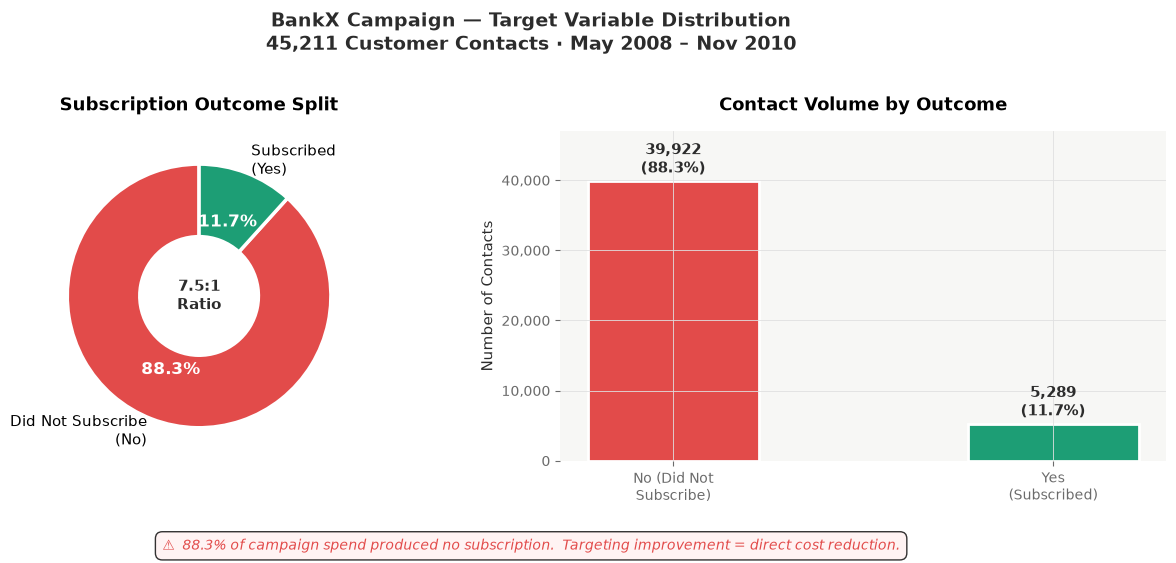


📊 Key numbers:
   Total contacts      : 45,211
   Subscriptions       : 5,289  (11.70%)
   Non-subscriptions   : 39,922 (88.30%)
   Class imbalance     : 7.5:1  (no:yes)
   Est. wasted spend   : ₹59.9 Lakh  (non-converting calls @ ₹150/call)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BankX Campaign — Target Variable Distribution\n'
             '45,211 Customer Contacts · May 2008 – Nov 2010',
             fontsize=14, fontweight='bold', color=NEUTRAL_DARK, y=1.02)

# ── Left: Donut chart ─────────────────────────────────────────────────────────
counts = df['y'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=['Did Not Subscribe\n(No)', 'Subscribed\n(Yes)'],
    colors=[BRAND_RED, BRAND_GREEN],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 11})
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold'); at.set_fontsize(12)
axes[0].set_title('Subscription Outcome Split', pad=15)
axes[0].text(0, 0, '7.5:1\nRatio', ha='center', va='center',
             fontsize=11, color=NEUTRAL_DARK, fontweight='bold')

# ── Right: Bar with annotations ───────────────────────────────────────────────
values = [39922, 5289]
bars = axes[1].bar(['No (Did Not\nSubscribe)', 'Yes\n(Subscribed)'],
                   values, color=[BRAND_RED, BRAND_GREEN],
                   width=0.45, edgecolor='white', linewidth=2)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 450,
                 f'{val:,}\n({val/45211*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color=NEUTRAL_DARK)
axes[1].set_title('Contact Volume by Outcome', pad=15)
axes[1].set_ylabel('Number of Contacts')
axes[1].set_ylim(0, 47000)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].set_facecolor(BG_LIGHT)

fig.text(0.5, -0.06,
    '⚠  88.3% of campaign spend produced no subscription.  '
    'Targeting improvement = direct cost reduction.',
    ha='center', fontsize=10, color=BRAND_RED, style='italic',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF0F0', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📊 Key numbers:")
print(f"   Total contacts      : 45,211")
print(f"   Subscriptions       : 5,289  (11.70%)")
print(f"   Non-subscriptions   : 39,922 (88.30%)")
print(f"   Class imbalance     : 7.5:1  (no:yes)")
print(f"   Est. wasted spend   : ₹59.9 Lakh  (non-converting calls @ ₹150/call)")

---
## Section 4 — Univariate Analysis: Numeric Features

**What to look for in each distribution:**
- **age** — roughly normal; the long right tail (elderly customers) will matter in segmentation
- **balance** — severely right-skewed; median (448 EUR) << mean (1,362 EUR) due to high-balance outliers
- **duration** — right-skewed; most calls are short, with a long tail of substantive conversations
- **campaign** — 75th percentile is 3 contacts; extreme values (up to 63) are campaign fatigue red flags
- **pdays** — bimodal spike at -1 (81.7% never contacted before) makes this non-continuous in practice
- **previous** — heavily zero-inflated; most customers have no prior campaign history

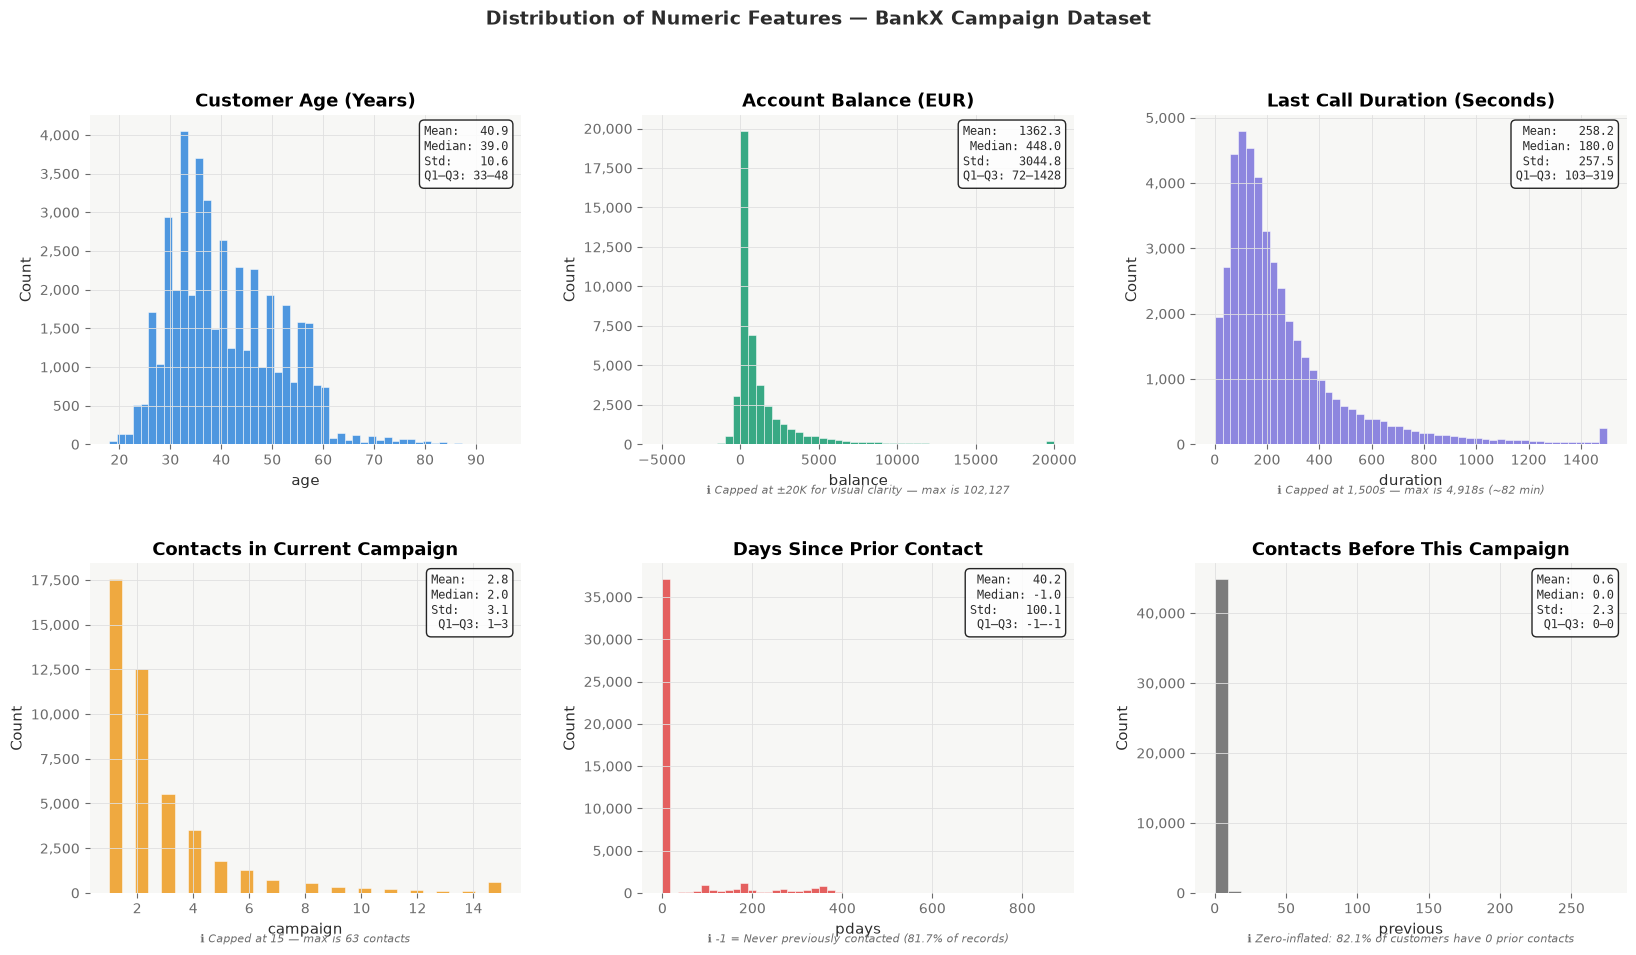

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Distribution of Numeric Features — BankX Campaign Dataset',
             fontsize=14, fontweight='bold', color=NEUTRAL_DARK)

configs = {
    'age'     : ('Customer Age (Years)',           BRAND_BLUE,   None,         None,  ''),
    'balance' : ('Account Balance (EUR)',           BRAND_GREEN,  -5000,        20000, 'Capped at ±20K for visual clarity — max is 102,127'),
    'duration': ('Last Call Duration (Seconds)',    BRAND_PURPLE, 0,            1500,  'Capped at 1,500s — max is 4,918s (~82 min)'),
    'campaign': ('Contacts in Current Campaign',    BRAND_AMBER,  0,            15,    'Capped at 15 — max is 63 contacts'),
    'pdays'   : ('Days Since Prior Contact',        BRAND_RED,    None,         None,  '-1 = Never previously contacted (81.7% of records)'),
    'previous': ('Contacts Before This Campaign',   NEUTRAL_MID,  None,         None,  'Zero-inflated: 82.1% of customers have 0 prior contacts'),
}

for ax, (col, (label, color, lo, hi, note)) in zip(axes.flatten(), configs.items()):
    data = df[col].clip(lo, hi) if (lo is not None or hi is not None) else df[col]
    n_bins = 50 if col not in ['campaign','previous'] else 30
    ax.hist(data, bins=n_bins, color=color, edgecolor='white', linewidth=0.4, alpha=0.88)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

    # Stats annotation box
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    stats_text = (f"Mean:   {df[col].mean():.1f}\n"
                  f"Median: {df[col].median():.1f}\n"
                  f"Std:    {df[col].std():.1f}\n"
                  f"Q1–Q3: {q1:.0f}–{q3:.0f}")
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, color=NEUTRAL_DARK, family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    if note:
        ax.text(0.5, -0.15, f'ℹ {note}', transform=ax.transAxes,
                ha='center', fontsize=8, color=NEUTRAL_MID, style='italic')

plt.tight_layout(pad=3.0)
plt.show()

---
## Section 5 — Univariate Analysis: Categorical Features

Key observations before segmentation:
- **job**: blue-collar (9,732) and management (9,458) are the two largest segments
- **marital**: married customers dominate (55.8%) — important for filtering
- **contact**: 28.8% "unknown" contact method — a legacy data quality issue
- **poutcome**: 81.7% "unknown" — means first-time campaign contact, not a data gap

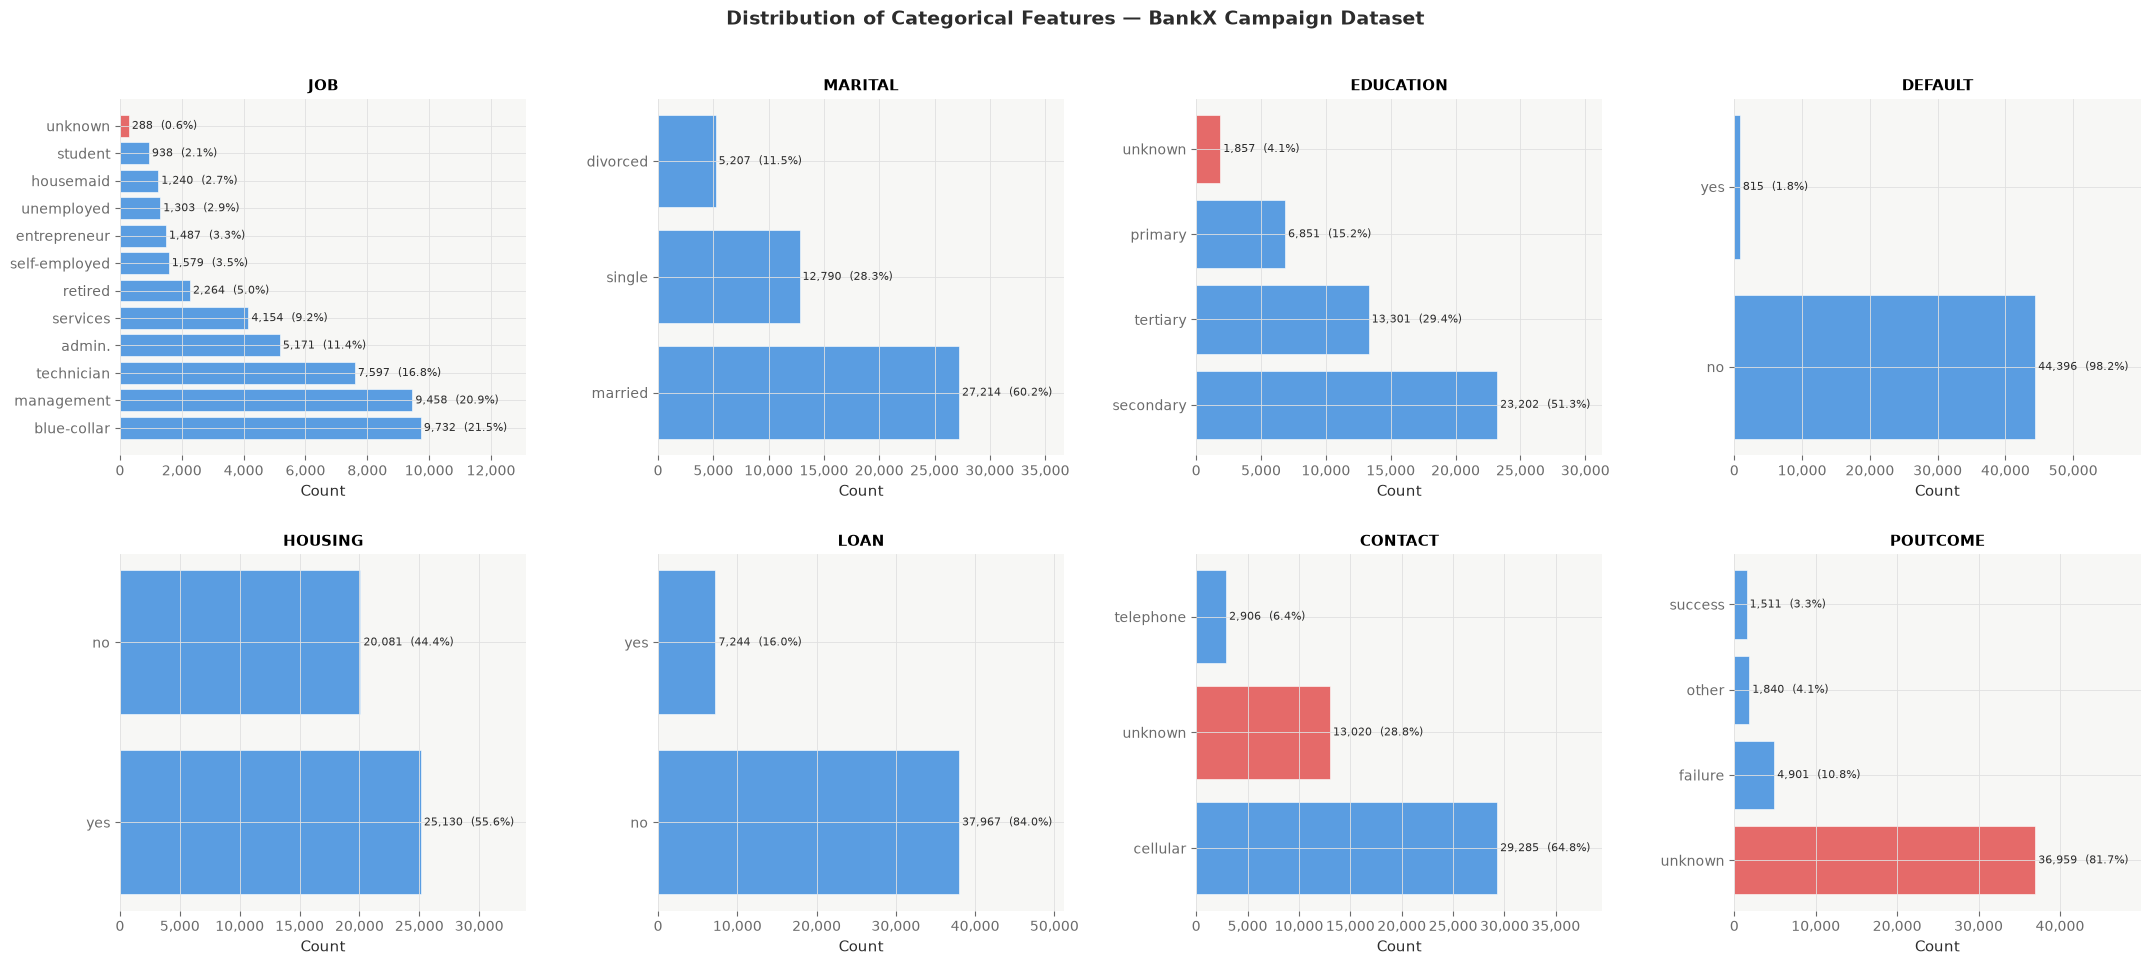

📊 Notable categorical findings:
   Largest job segment  : blue-collar  (9,732 contacts = 21.5%)
   Unknown contact type : 13,020  (28.8%) — legacy data, not missing values
   poutcome = unknown   : 36,959  (81.7%) — first-time contacts, not data gaps
   Credit defaults      : 815     (1.8%)  — small but relevant for risk targeting


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Distribution of Categorical Features — BankX Campaign Dataset',
             fontsize=14, fontweight='bold', color=NEUTRAL_DARK)

cat_cols = ['job','marital','education','default','housing','loan','contact','poutcome']

for ax, col in zip(axes.flatten(), cat_cols):
    vc  = df[col].value_counts()
    pct = vc / len(df) * 100

    # Colour bars: highlight unknowns differently
    bar_colors = [BRAND_RED if v == 'unknown' else BRAND_BLUE for v in vc.index]
    bars = ax.barh(vc.index, vc.values, color=bar_colors, alpha=0.82, edgecolor='white', linewidth=0.5)

    for bar, (val, p) in zip(bars, zip(vc.values, pct.values)):
        ax.text(bar.get_width() + vc.values.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}  ({p:.1f}%)', va='center', fontsize=8.2, color=NEUTRAL_DARK)

    ax.set_title(col.upper(), fontweight='bold', fontsize=11)
    ax.set_xlabel('Count')
    ax.set_xlim(0, vc.values.max() * 1.35)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout(pad=2.5)
plt.show()

print("📊 Notable categorical findings:")
print(f"   Largest job segment  : blue-collar  (9,732 contacts = 21.5%)")
print(f"   Unknown contact type : 13,020  (28.8%) — legacy data, not missing values")
print(f"   poutcome = unknown   : 36,959  (81.7%) — first-time contacts, not data gaps")
print(f"   Credit defaults      : 815     (1.8%)  — small but relevant for risk targeting")

---
## Section 6 — Bivariate Analysis: Conversion by Job Type

> The core question: **which occupation converts most?**
> Conversion lift = segment rate ÷ overall average (11.70%).
> Lift > 1.0 means the segment outperforms; lift < 1.0 means underperforms.

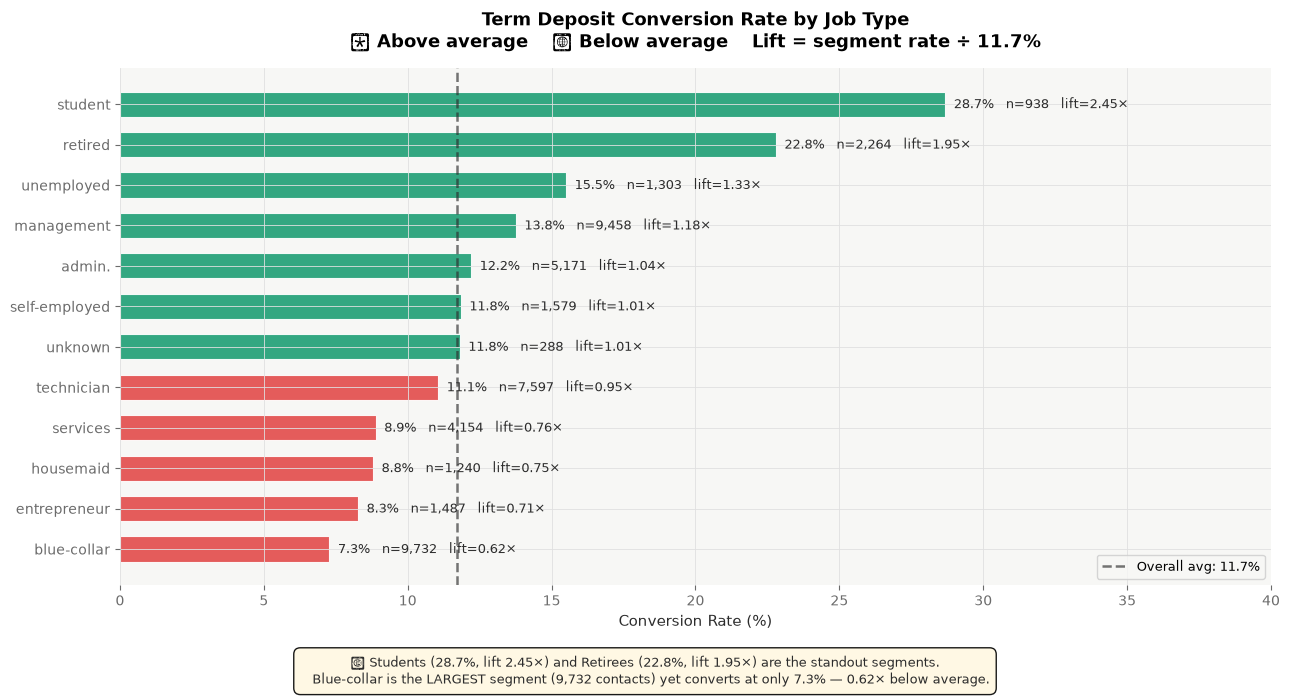


📊 Top 5 job segments by conversion rate:
       job  contacts  subscriptions  rate_pct     lift
   student       938            269 28.678038 2.451114
   retired      2264            516 22.791519 1.947993
unemployed      1303            202 15.502686 1.325016
management      9458           1301 13.755551 1.175688
    admin.      5171            631 12.202669 1.042963


In [8]:
job_conv = (df.groupby('job')['subscription_flag']
              .agg(contacts='count', subscriptions='sum')
              .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100,
                      lift=lambda x: x['subscriptions']/x['contacts']/0.117)
              .sort_values('rate_pct', ascending=True)
              .reset_index())

fig, ax = plt.subplots(figsize=(13, 6.5))
bar_colors = [BRAND_GREEN if r >= 11.7 else BRAND_RED for r in job_conv['rate_pct']]
bars = ax.barh(job_conv['job'], job_conv['rate_pct'],
               color=bar_colors, edgecolor='white', linewidth=0.8, height=0.62, alpha=0.9)

for bar, (_, row) in zip(bars, job_conv.iterrows()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{row['rate_pct']:.1f}%   n={row['contacts']:,}   lift={row['lift']:.2f}×",
            va='center', fontsize=9, color=NEUTRAL_DARK)

ax.axvline(x=11.7, color=NEUTRAL_DARK, linestyle='--',
           linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
ax.set_xlabel('Conversion Rate (%)')
ax.set_title('Term Deposit Conversion Rate by Job Type\n'
             '🟢 Above average    🔴 Below average    Lift = segment rate ÷ 11.7%', pad=15)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 40)
ax.set_facecolor(BG_LIGHT)

fig.text(0.5, -0.06,
    '💡 Students (28.7%, lift 2.45×) and Retirees (22.8%, lift 1.95×) are the standout segments.\n'
    '   Blue-collar is the LARGEST segment (9,732 contacts) yet converts at only 7.3% — 0.62× below average.',
    ha='center', fontsize=9.5, color=NEUTRAL_DARK,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF8E1', alpha=0.9))

plt.tight_layout()
plt.show()

print("\n📊 Top 5 job segments by conversion rate:")
print(job_conv[['job','contacts','subscriptions','rate_pct','lift']].tail(5)
      .sort_values('rate_pct', ascending=False)
      .to_string(index=False))

---
## Section 7 — Bivariate Analysis: Conversion by Age Band

> **Standout finding:** Retired customers (61+) convert at **42.26%** — nearly 4× the overall average.
> This is the single highest-converting demographic dimension in the dataset.
> Business implication: retirees have pension capital to deploy and lower debt obligations.

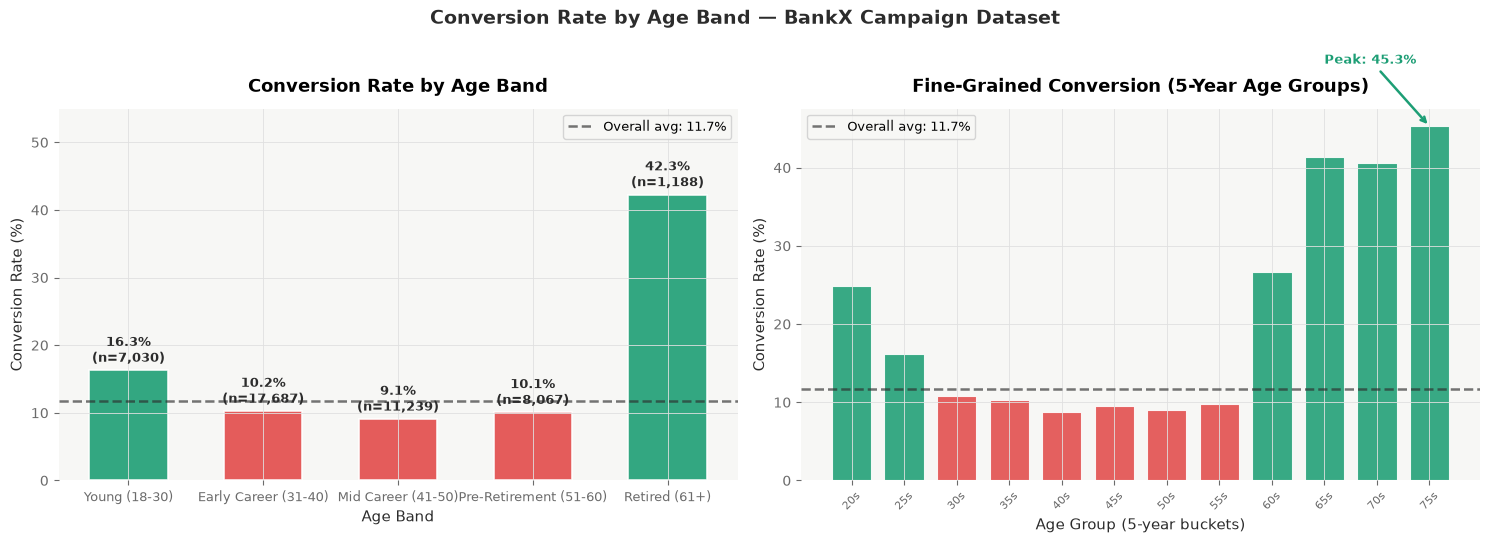


📊 Age band conversion summary:
              age_band  contacts  subscriptions  rate_pct
         Young (18-30)      7030           1145 16.287340
  Early Career (31-40)     17687           1812 10.244813
    Mid Career (41-50)     11239           1019  9.066643
Pre-Retirement (51-60)      8067            811 10.053304
         Retired (61+)      1188            502 42.255892


In [9]:
age_conv = (df.groupby('age_band', observed=True)['subscription_flag']
              .agg(contacts='count', subscriptions='sum')
              .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Conversion Rate by Age Band — BankX Campaign Dataset',
             fontsize=14, fontweight='bold', color=NEUTRAL_DARK)

# ── Left: Bar chart ───────────────────────────────────────────────────────────
bar_cols = [BRAND_GREEN if r >= 11.7 else BRAND_RED for r in age_conv['rate_pct']]
bars = axes[0].bar(age_conv['age_band'].astype(str), age_conv['rate_pct'],
                   color=bar_cols, edgecolor='white', linewidth=1.2, width=0.58, alpha=0.9)
for bar, (_, row) in zip(bars, age_conv.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.6,
                 f"{row['rate_pct']:.1f}%\n(n={row['contacts']:,})",
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=NEUTRAL_DARK)
axes[0].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('Age Band')
axes[0].set_title('Conversion Rate by Age Band', pad=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 55)
axes[0].tick_params(axis='x', labelsize=9)

# ── Right: Fine-grained 5-year buckets ───────────────────────────────────────
df['age_5yr'] = (df['age'] // 5) * 5
fine = (df.groupby('age_5yr')['subscription_flag']
          .agg(contacts='count', subscriptions='sum')
          .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
          .reset_index())
fine = fine[fine['contacts'] >= 100]  # Minimum sample size

bar_cols2 = [BRAND_GREEN if r >= 11.7 else BRAND_RED for r in fine['rate_pct']]
axes[1].bar(fine['age_5yr'].astype(str) + 's', fine['rate_pct'],
            color=bar_cols2, edgecolor='white', linewidth=0.8, width=0.75, alpha=0.88)
axes[1].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xlabel('Age Group (5-year buckets)')
axes[1].set_title('Fine-Grained Conversion (5-Year Age Groups)', pad=12)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

# Annotate the 60s+ spike
peak_age = fine.loc[fine['rate_pct'].idxmax()]
axes[1].annotate(f"Peak: {peak_age['rate_pct']:.1f}%",
                xy=(fine['rate_pct'].idxmax() - fine.index[0], peak_age['rate_pct']),
                xytext=(fine['rate_pct'].idxmax() - fine.index[0] - 2, peak_age['rate_pct'] + 8),
                arrowprops=dict(arrowstyle='->', color=BRAND_GREEN, lw=1.8),
                fontsize=9, color=BRAND_GREEN, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Age band conversion summary:")
print(age_conv[['age_band','contacts','subscriptions','rate_pct']].to_string(index=False))

---
## Section 8 — The Warm Lead Multiplier

> **Most important single finding in the project.**
> Customers who subscribed in a previous campaign (`poutcome = success`)
> convert at **64.73%** in the current campaign — a **7× multiplier** over cold leads.
>
> These 1,511 customers should be the **first call every campaign, every time.**
> The ROI difference between warm and cold leads is the strongest argument
> for a segmented calling strategy.

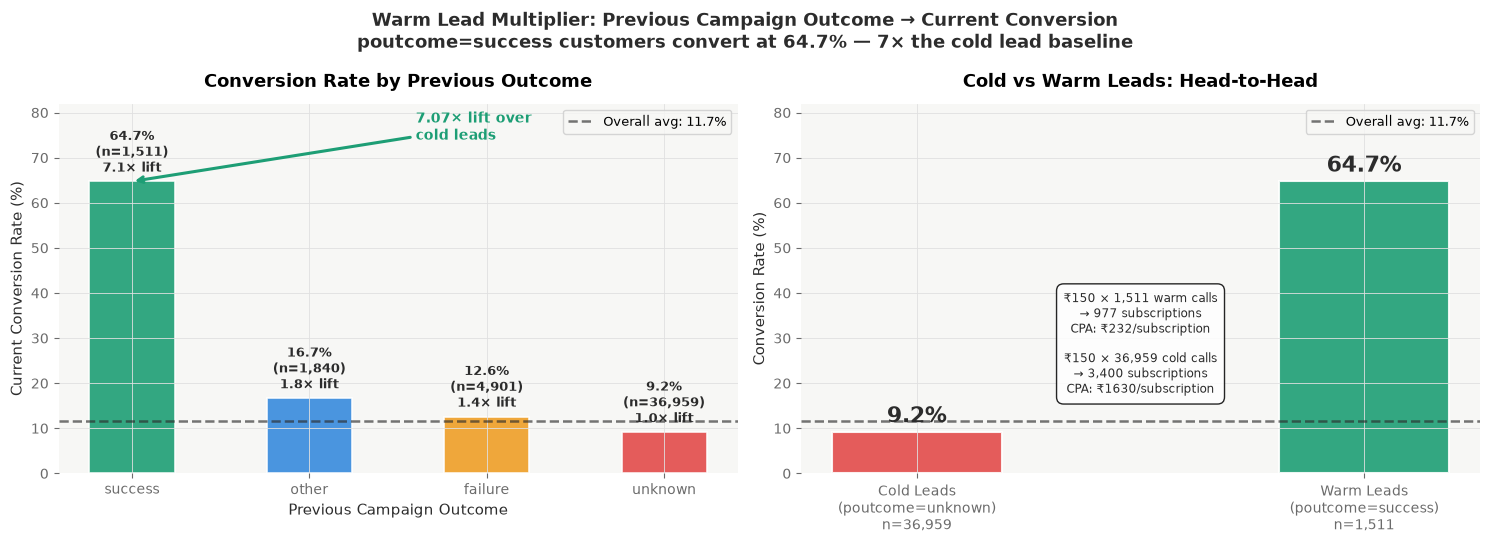


📊 Warm lead multiplier summary:
poutcome  contacts  subscriptions  rate_pct  lift_vs_cold
 success      1511            978 64.725347          7.06
   other      1840            307 16.684783          1.82
 failure      4901            618 12.609671          1.38
 unknown     36959           3386  9.161503          1.00


In [10]:
pout_conv = (df.groupby('poutcome')['subscription_flag']
               .agg(contacts='count', subscriptions='sum')
               .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
               .sort_values('rate_pct', ascending=False)
               .reset_index())

# Compute lift vs cold (unknown) baseline
cold_rate = pout_conv.loc[pout_conv['poutcome']=='unknown','rate_pct'].values[0]
pout_conv['lift_vs_cold'] = (pout_conv['rate_pct'] / cold_rate).round(2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Warm Lead Multiplier: Previous Campaign Outcome → Current Conversion\n'
             'poutcome=success customers convert at 64.7% — 7× the cold lead baseline',
             fontsize=13, fontweight='bold', color=NEUTRAL_DARK)

color_map = {'success':'#1D9E75','other':'#378ADD','failure':'#EF9F27','unknown':'#E24B4A'}

# ── Left: conversion rate bars ────────────────────────────────────────────────
bars = axes[0].bar(pout_conv['poutcome'],
                   pout_conv['rate_pct'],
                   color=[color_map[p] for p in pout_conv['poutcome']],
                   edgecolor='white', linewidth=1.2, width=0.48, alpha=0.9)
for bar, (_, row) in zip(bars, pout_conv.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.2,
                 f"{row['rate_pct']:.1f}%\n(n={row['contacts']:,})\n{row['lift_vs_cold']:.1f}× lift",
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=NEUTRAL_DARK)
axes[0].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[0].set_xlabel('Previous Campaign Outcome')
axes[0].set_ylabel('Current Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Previous Outcome', pad=12)
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 82)
axes[0].annotate('7.07× lift over\ncold leads',
                 xy=(0, 64.73), xytext=(1.6, 74),
                 arrowprops=dict(arrowstyle='->', color=BRAND_GREEN, lw=2.2),
                 fontsize=10, color=BRAND_GREEN, fontweight='bold')

# ── Right: warm vs cold binary comparison ────────────────────────────────────
warm_rate = pout_conv.loc[pout_conv['poutcome']=='success','rate_pct'].values[0]
warm_n    = pout_conv.loc[pout_conv['poutcome']=='success','contacts'].values[0]
cold_n    = pout_conv.loc[pout_conv['poutcome']=='unknown','contacts'].values[0]

comparison_df = pd.DataFrame({
    'Segment': ['Cold Leads\n(poutcome=unknown)\nn=36,959',
                'Warm Leads\n(poutcome=success)\nn=1,511'],
    'Rate'   : [cold_rate, warm_rate],
    'Color'  : [BRAND_RED, BRAND_GREEN]
})
bars2 = axes[1].bar(comparison_df['Segment'], comparison_df['Rate'],
                    color=comparison_df['Color'], edgecolor='white',
                    linewidth=1.5, width=0.38, alpha=0.9)
for bar, val in zip(bars2, comparison_df['Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.0,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=16, fontweight='bold', color=NEUTRAL_DARK)
axes[1].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Cold vs Warm Leads: Head-to-Head', pad=12)
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 82)

# ROI callout
axes[1].text(0.5, 0.35,
    f'₹150 × {warm_n:,} warm calls\n→ {int(warm_n*0.647):,} subscriptions\n'
    f'CPA: ₹{150/0.647:.0f}/subscription\n\n'
    f'₹150 × {cold_n:,} cold calls\n→ {int(cold_n*0.092):,} subscriptions\n'
    f'CPA: ₹{150/0.092:.0f}/subscription',
    transform=axes[1].transAxes, ha='center', va='center',
    fontsize=8.5, color=NEUTRAL_DARK,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85))

plt.tight_layout()
plt.show()

print("\n📊 Warm lead multiplier summary:")
print(pout_conv[['poutcome','contacts','subscriptions','rate_pct','lift_vs_cold']].to_string(index=False))

---
## Section 9 — Monthly Volume vs Conversion Rate

> **Critical operational finding:**
> **May** accounts for 30.4% of all contacts (13,766 calls) but produces the **lowest conversion rate** in the dataset at **6.7%**.
> Meanwhile **March** (477 calls, 1.1% of volume) converts at **52.0%**.
>
> The bank is running its biggest effort in its worst month.
> Shifting even 20% of May's calling budget to September–December
> would produce materially better campaign ROI.

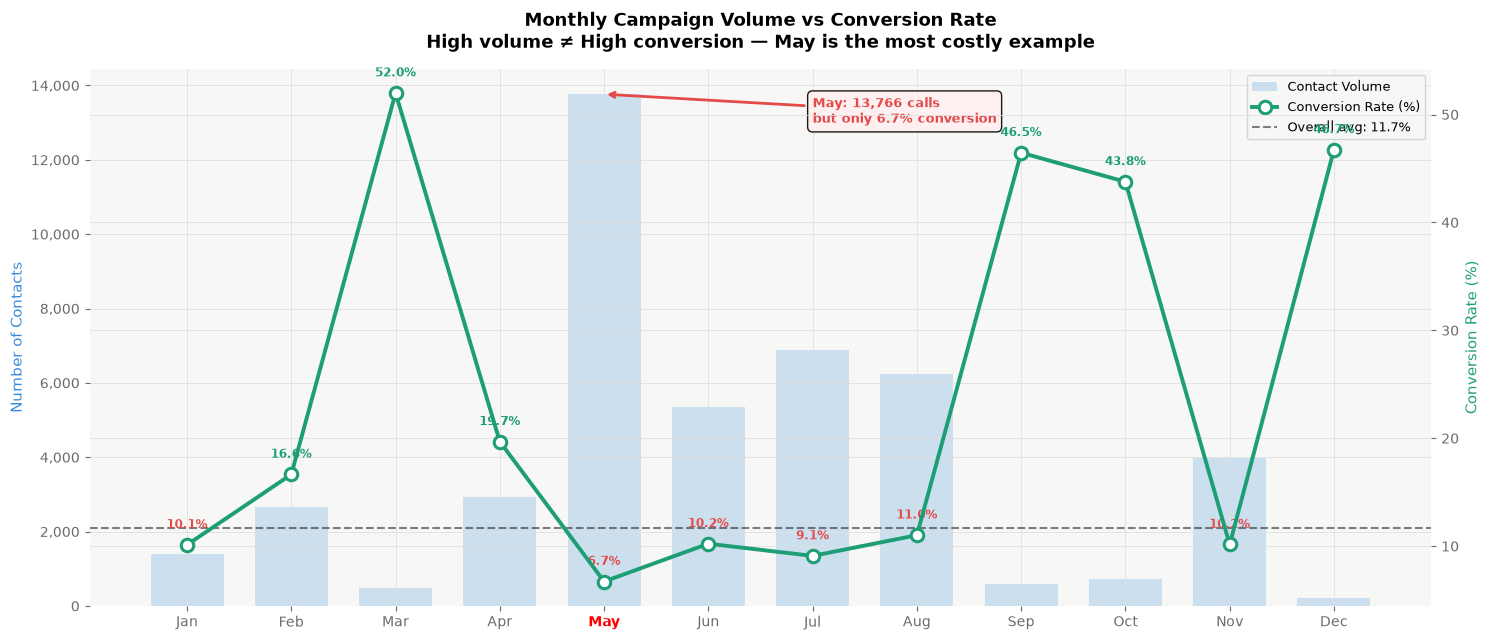


📊 Ranked by conversion rate (best to worst):
month_label  contacts  subscriptions  conv_rate_%  calls/subscription
        Mar       477            248    51.991614            1.923387
        Dec       214            100    46.728972            2.140000
        Sep       579            269    46.459413            2.152416
        Oct       738            323    43.766938            2.284830
        Apr      2932            577    19.679400            5.081456
        Feb      2649            441    16.647792            6.006803
        Aug      6247            688    11.013286            9.079942
        Jun      5341            546    10.222805            9.782051
        Nov      3970            403    10.151134            9.851117
        Jan      1403            142    10.121169            9.880282
        Jul      6895            627     9.093546           10.996810
        May     13766            925     6.719454           14.882162


In [11]:
month_df = (df.groupby(['month_num','month_label'])['subscription_flag']
              .agg(contacts='count', subscriptions='sum')
              .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100,
                      calls_per_sub=lambda x: x['contacts']/x['subscriptions'])
              .reset_index()
              .sort_values('month_num'))

fig, ax1 = plt.subplots(figsize=(15, 6.5))
ax2 = ax1.twinx()

# Volume bars
ax1.bar(month_df['month_label'], month_df['contacts'],
        color=BRAND_BLUE, alpha=0.22, edgecolor='none', width=0.7, label='Contact Volume')

# Conversion rate line
ax2.plot(month_df['month_label'], month_df['rate_pct'],
         color=BRAND_GREEN, linewidth=2.8, marker='o', markersize=9,
         markerfacecolor='white', markeredgecolor=BRAND_GREEN,
         markeredgewidth=2.2, label='Conversion Rate (%)', zorder=5)
ax2.axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
            linewidth=1.5, alpha=0.6, label='Overall avg: 11.7%')

# Data labels on conversion line
for _, row in month_df.iterrows():
    color = BRAND_GREEN if row['rate_pct'] >= 11.7 else BRAND_RED
    ax2.annotate(f"{row['rate_pct']:.1f}%",
                 xy=(row['month_label'], row['rate_pct']),
                 xytext=(0, 12), textcoords='offset points',
                 ha='center', fontsize=8.5, color=color, fontweight='bold')

# Annotate May problem
may_row = month_df[month_df['month_label']=='May'].iloc[0]
ax1.annotate(f"May: 13,766 calls\nbut only {may_row['rate_pct']:.1f}% conversion",
             xy=('May', may_row['contacts']),
             xytext=('Jul', 13000),
             arrowprops=dict(arrowstyle='->', color=BRAND_RED, lw=2),
             fontsize=9, color=BRAND_RED, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF0F0', alpha=0.9))

ax1.set_ylabel('Number of Contacts', color=BRAND_BLUE, fontsize=11)
ax2.set_ylabel('Conversion Rate (%)', color=BRAND_GREEN, fontsize=11)
ax1.set_title('Monthly Campaign Volume vs Conversion Rate\n'
              'High volume ≠ High conversion — May is the most costly example',
              pad=15, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Highlight May in red on x-axis
tick_colors = ['red' if m == 'May' else NEUTRAL_MID
               for m in month_df['month_label']]
for label, color in zip(ax1.get_xticklabels(), tick_colors):
    label.set_color(color)
    if color == 'red': label.set_fontweight('bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Ranked by conversion rate (best to worst):")
print(month_df[['month_label','contacts','subscriptions','rate_pct','calls_per_sub']]
      .sort_values('rate_pct', ascending=False)
      .rename(columns={'rate_pct':'conv_rate_%','calls_per_sub':'calls/subscription'})
      .to_string(index=False))

---
## Section 10 — Campaign Fatigue Curve

> **Actionable finding:** Conversion rate decays from **14.6% on the first call** to **5.8% after 6+ calls** — a 60% relative decline.
>
> Customers called 4+ times in a single campaign represent wasted spend.
> A simple **"3-call cap" policy** would eliminate low-ROI contacts
> while retaining the majority of subscription volume.
>
> This is the easiest, most immediate recommendation for the campaign manager.

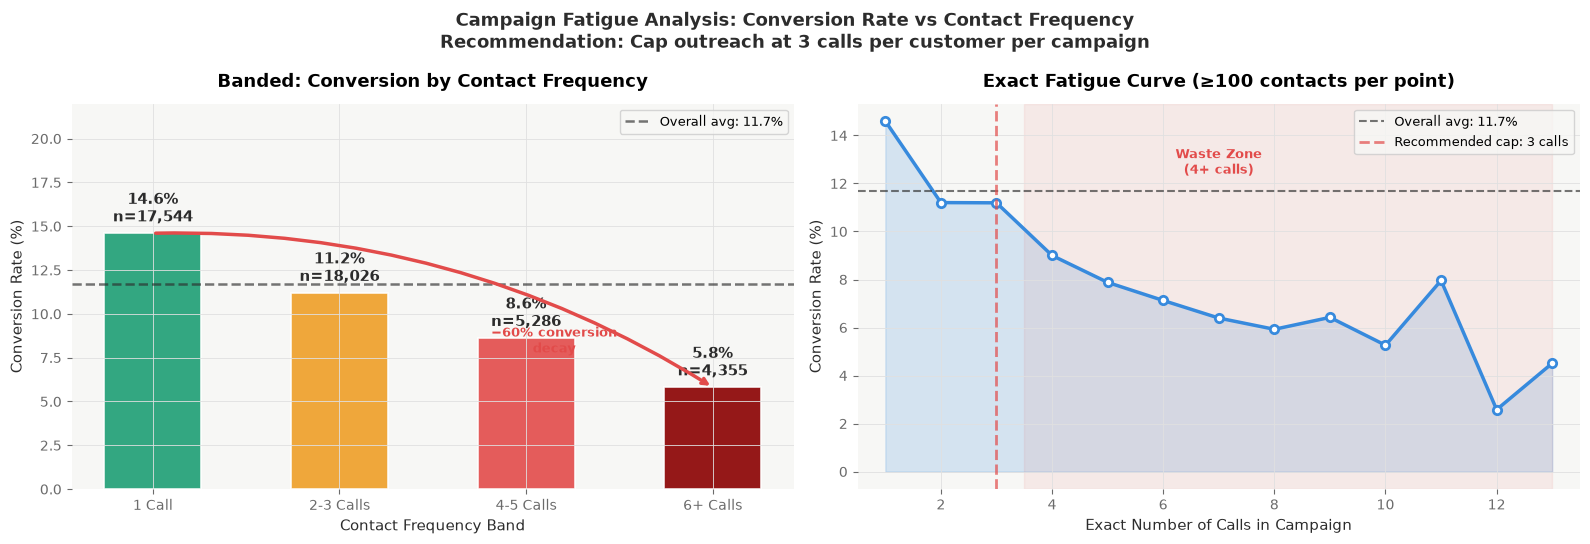


📊 Campaign fatigue: banded summary
contact_freq_band  contacts  subscriptions  rate_pct
           1 Call     17544           2561 14.597583
        2-3 Calls     18026           2019 11.200488
        4-5 Calls      5286            456  8.626561
         6+ Calls      4355            253  5.809414

💡 Budget implication of 3-call cap:
   Calls eliminated : 9,641  (21.3% of total)
   Spend saved      : ₹14.46 Lakh  (@ ₹150/call)
   Subscriptions lost: 709  (7.4% conversion in this band)


In [12]:
fatigue_df = (df.groupby('contact_freq_band', observed=True)['subscription_flag']
                .agg(contacts='count', subscriptions='sum')
                .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
                .reset_index())

# Also compute exact per-call-count curve
exact_df = (df.groupby('campaign')['subscription_flag']
              .agg(contacts='count', subscriptions='sum')
              .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
              .reset_index())
exact_df = exact_df[exact_df['contacts'] >= 100]  # Min sample size

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Campaign Fatigue Analysis: Conversion Rate vs Contact Frequency\n'
             'Recommendation: Cap outreach at 3 calls per customer per campaign',
             fontsize=13, fontweight='bold', color=NEUTRAL_DARK)

# ── Left: Banded bar chart ────────────────────────────────────────────────────
palette = [BRAND_GREEN, BRAND_AMBER, BRAND_RED, '#8B0000']
bars = axes[0].bar(fatigue_df['contact_freq_band'].astype(str),
                   fatigue_df['rate_pct'],
                   color=palette, edgecolor='white', linewidth=1.2,
                   width=0.52, alpha=0.9)
for bar, (_, row) in zip(bars, fatigue_df.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f"{row['rate_pct']:.1f}%\nn={row['contacts']:,}",
                 ha='center', va='bottom', fontsize=10.5, fontweight='bold', color=NEUTRAL_DARK)
axes[0].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')

# Decay annotation
axes[0].annotate('', xy=(3, 5.81), xytext=(0, 14.60),
                arrowprops=dict(arrowstyle='->', color=BRAND_RED, lw=2.5,
                               connectionstyle='arc3,rad=-0.15'))
axes[0].text(2.15, 7.8, '−60% conversion\ndecay', color=BRAND_RED,
             fontsize=9.5, fontweight='bold', ha='center')

axes[0].set_xlabel('Contact Frequency Band')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Banded: Conversion by Contact Frequency', pad=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 22)

# ── Right: Exact per-call-count curve ────────────────────────────────────────
axes[1].fill_between(exact_df['campaign'], exact_df['rate_pct'],
                     alpha=0.18, color=BRAND_BLUE)
axes[1].plot(exact_df['campaign'], exact_df['rate_pct'],
             color=BRAND_BLUE, linewidth=2.5, marker='o',
             markersize=6, markerfacecolor='white',
             markeredgecolor=BRAND_BLUE, markeredgewidth=2)
axes[1].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.5, alpha=0.65, label='Overall avg: 11.7%')
axes[1].axvline(x=3, color=BRAND_RED, linestyle='--',
                linewidth=2, alpha=0.7, label='Recommended cap: 3 calls')

axes[1].set_xlabel('Exact Number of Calls in Campaign')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Exact Fatigue Curve (≥100 contacts per point)', pad=12)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.5, exact_df['campaign'].max() + 0.5)

# Shade "waste zone"
axes[1].axvspan(3.5, exact_df['campaign'].max(), alpha=0.08,
                color=BRAND_RED, label='Waste zone (4+ calls)')
axes[1].text(7, exact_df['rate_pct'].max() * 0.85,
             'Waste Zone\n(4+ calls)', color=BRAND_RED,
             fontsize=9, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Campaign fatigue: banded summary")
print(fatigue_df[['contact_freq_band','contacts','subscriptions','rate_pct']].to_string(index=False))
print(f"\n💡 Budget implication of 3-call cap:")
excess = df[df['campaign'] > 3]
print(f"   Calls eliminated : {len(excess):,}  ({len(excess)/len(df)*100:.1f}% of total)")
print(f"   Spend saved      : ₹{len(excess)*150/100000:.2f} Lakh  (@ ₹150/call)")
print(f"   Subscriptions lost: {excess['subscription_flag'].sum():,}  ({excess['subscription_flag'].mean()*100:.1f}% conversion in this band)")

---
## Section 11 — Debt Burden Impact on Conversion

> **Clearest negative predictor in the dataset.**
> Customers who are **debt-free** convert at **18.22%** — 3× better than customers
> carrying both a housing loan AND a personal loan (6.07%).
>
> The intuition is straightforward: customers with dual debt obligations
> have less disposable income to lock into a fixed-tenure savings product.
> This makes `housing=yes AND loan=yes` a reliable **exclusion signal** for low-priority calling.

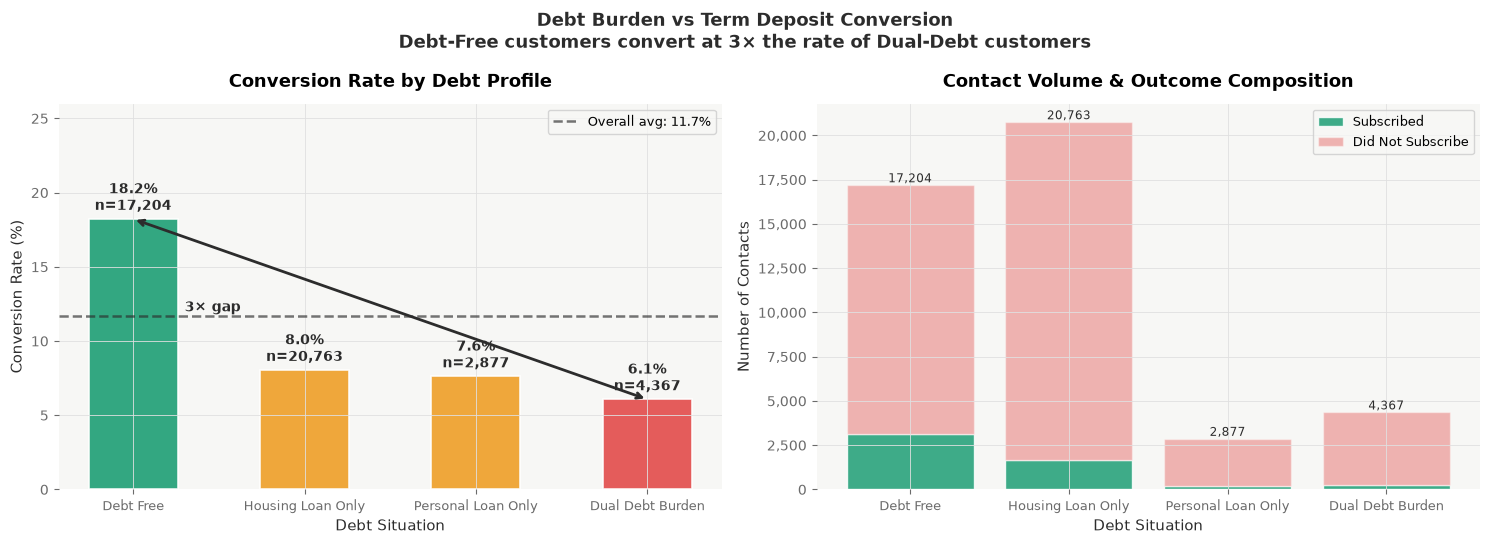


📊 Debt burden conversion summary:
       debt_burden  contacts  subscriptions  rate_pct
         Debt Free     17204           3135 18.222506
 Housing Loan Only     20763           1670  8.043154
Personal Loan Only      2877            219  7.612096
  Dual Debt Burden      4367            265  6.068239


In [13]:
debt_order = ['Debt Free', 'Housing Loan Only', 'Personal Loan Only', 'Dual Debt Burden']
debt_conv = (df.groupby('debt_burden')['subscription_flag']
               .agg(contacts='count', subscriptions='sum')
               .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
               .reindex(debt_order)
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Debt Burden vs Term Deposit Conversion\n'
             'Debt-Free customers convert at 3× the rate of Dual-Debt customers',
             fontsize=13, fontweight='bold', color=NEUTRAL_DARK)

# ── Left: Bar chart ───────────────────────────────────────────────────────────
palette_d = [BRAND_GREEN, BRAND_AMBER, BRAND_AMBER, BRAND_RED]
bars = axes[0].bar(debt_conv['debt_burden'], debt_conv['rate_pct'],
                   color=palette_d, edgecolor='white', linewidth=1.2,
                   width=0.52, alpha=0.9)
for bar, (_, row) in zip(bars, debt_conv.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row['rate_pct']:.1f}%\nn={row['contacts']:,}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color=NEUTRAL_DARK)
axes[0].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('Debt Situation')
axes[0].set_title('Conversion Rate by Debt Profile', pad=12)
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 26)
axes[0].tick_params(axis='x', labelsize=9)

# Span annotation — gap between Debt Free and Dual Debt
axes[0].annotate('', xy=(3, 6.07), xytext=(0, 18.22),
                arrowprops=dict(arrowstyle='<->', color=NEUTRAL_DARK, lw=2))
axes[0].text(0.3, 12, '3× gap', fontsize=10, color=NEUTRAL_DARK, fontweight='bold')

# ── Right: Stacked composition chart ─────────────────────────────────────────
debt_conv['non_sub'] = debt_conv['contacts'] - debt_conv['subscriptions']
axes[1].bar(debt_conv['debt_burden'], debt_conv['subscriptions'],
            color=BRAND_GREEN, alpha=0.85, label='Subscribed', edgecolor='white')
axes[1].bar(debt_conv['debt_burden'], debt_conv['non_sub'],
            bottom=debt_conv['subscriptions'],
            color=BRAND_RED, alpha=0.4, label='Did Not Subscribe', edgecolor='white')

for _, row in debt_conv.iterrows():
    axes[1].text(debt_order.index(row['debt_burden']),
                 row['contacts'] + 150,
                 f"{row['contacts']:,}", ha='center', fontsize=8.5, color=NEUTRAL_DARK)

axes[1].set_ylabel('Number of Contacts')
axes[1].set_xlabel('Debt Situation')
axes[1].set_title('Contact Volume & Outcome Composition', pad=12)
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[1].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Debt burden conversion summary:")
print(debt_conv[['debt_burden','contacts','subscriptions','rate_pct']].to_string(index=False))

---
## Section 12 — Account Balance Tier Analysis

> Balance is the most direct proxy for a customer's **financial capacity** to lock money in a fixed-tenure product.
>
> Key finding: customers with **≥1,000 EUR average balance** convert at ~15% consistently across Medium, High, and Very High tiers — well above the 11.7% average.
> Negative balance customers (6.9% conversion) should be the **last priority** in any targeted campaign.

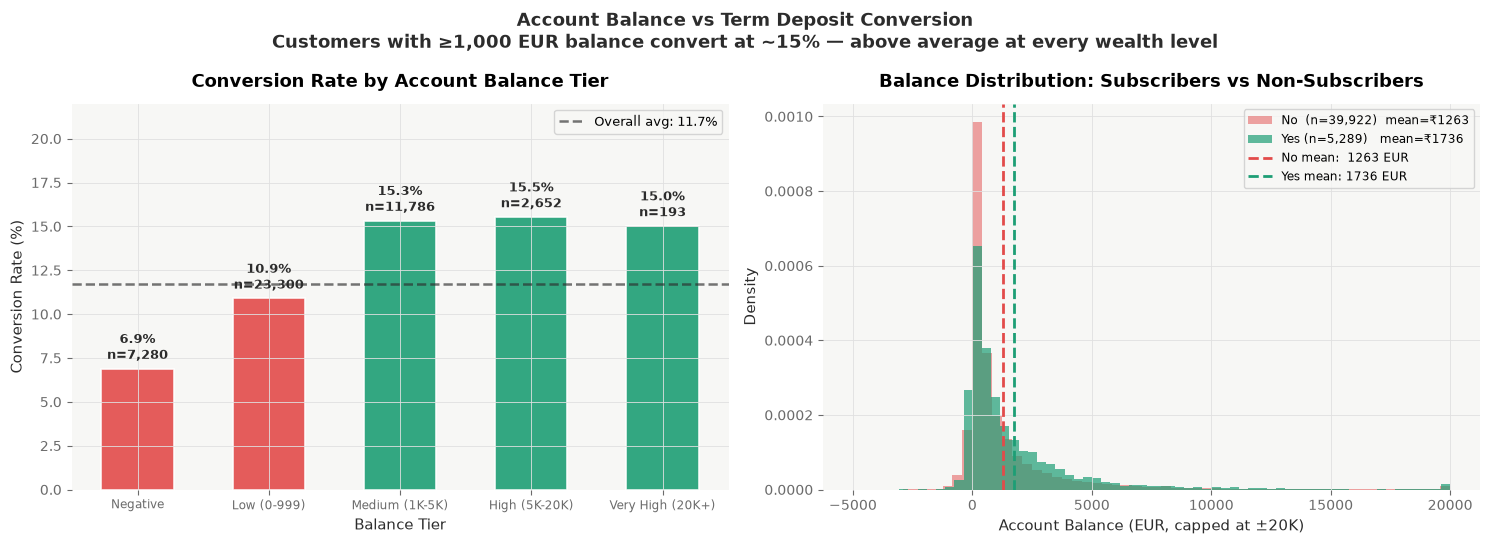


📊 Balance tier conversion summary:
    balance_tier  contacts  subscriptions  rate_pct
        Negative      7280            502  6.895604
     Low (0-999)     23300           2539 10.896996
  Medium (1K-5K)     11786           1807 15.331750
   High (5K-20K)      2652            412 15.535445
Very High (20K+)       193             29 15.025907

   Subscriber avg balance    : 1804 EUR
   Non-subscriber avg balance: 1304 EUR
   Difference                : +501 EUR (subscribers are wealthier)


In [14]:
bal_conv = (df.groupby('balance_tier', observed=True)['subscription_flag']
              .agg(contacts='count', subscriptions='sum')
              .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
              .reset_index())

# Subscriber vs non-subscriber balance distributions
yes_bal = df[df['y']=='yes']['balance'].clip(-5000, 20000)
no_bal  = df[df['y']=='no']['balance'].clip(-5000, 20000)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Account Balance vs Term Deposit Conversion\n'
             'Customers with ≥1,000 EUR balance convert at ~15% — above average at every wealth level',
             fontsize=13, fontweight='bold', color=NEUTRAL_DARK)

# ── Left: Conversion rate by balance tier ─────────────────────────────────────
bar_cols = [BRAND_RED, BRAND_RED, BRAND_GREEN, BRAND_GREEN, BRAND_GREEN]
bars = axes[0].bar(bal_conv['balance_tier'].astype(str),
                   bal_conv['rate_pct'],
                   color=bar_cols, edgecolor='white', linewidth=1.2,
                   width=0.55, alpha=0.9)
for bar, (_, row) in zip(bars, bal_conv.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{row['rate_pct']:.1f}%\nn={row['contacts']:,}",
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=NEUTRAL_DARK)
axes[0].axhline(y=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_xlabel('Balance Tier')
axes[0].set_title('Conversion Rate by Account Balance Tier', pad=12)
axes[0].legend(fontsize=9); axes[0].set_ylim(0, 22)
axes[0].tick_params(axis='x', labelsize=8.5)

# ── Right: Balance distribution by outcome (KDE style) ───────────────────────
axes[1].hist(no_bal,  bins=60, density=True, alpha=0.50,
             color=BRAND_RED,   label=f'No  (n=39,922)  mean=₹{no_bal.mean():.0f}', edgecolor='none')
axes[1].hist(yes_bal, bins=60, density=True, alpha=0.70,
             color=BRAND_GREEN, label=f'Yes (n=5,289)   mean=₹{yes_bal.mean():.0f}', edgecolor='none')
axes[1].axvline(no_bal.mean(),  color=BRAND_RED,   linestyle='--', linewidth=2,
                label=f'No mean:  {no_bal.mean():.0f} EUR')
axes[1].axvline(yes_bal.mean(), color=BRAND_GREEN, linestyle='--', linewidth=2,
                label=f'Yes mean: {yes_bal.mean():.0f} EUR')
axes[1].set_xlabel('Account Balance (EUR, capped at ±20K)')
axes[1].set_ylabel('Density')
axes[1].set_title('Balance Distribution: Subscribers vs Non-Subscribers', pad=12)
axes[1].legend(fontsize=8.5)

plt.tight_layout()
plt.show()

print("\n📊 Balance tier conversion summary:")
print(bal_conv[['balance_tier','contacts','subscriptions','rate_pct']].to_string(index=False))
print(f"\n   Subscriber avg balance    : {df[df['y']=='yes']['balance'].mean():.0f} EUR")
print(f"   Non-subscriber avg balance: {df[df['y']=='no']['balance'].mean():.0f} EUR")
print(f"   Difference                : +{df[df['y']=='yes']['balance'].mean()-df[df['y']=='no']['balance'].mean():.0f} EUR (subscribers are wealthier)")

---
## Section 13 — Call Duration Deep-Dive

> **Diagnostic finding — not a targeting signal.**
>
> Subscribers speak for **2.4× longer** on average (537s vs 221s).
> A Mann-Whitney U test confirms this difference is highly statistically significant (p < 0.001).
>
> **Important caveat:** call duration is only known *after* the call ends.
> It cannot be used to decide who to call. It *can* be used to:
> - Train agents to sustain longer, more substantive conversations
> - Flag calls below 60 seconds as "likely unengaged" for quality review
> - Validate that high-converting segments are producing longer average calls

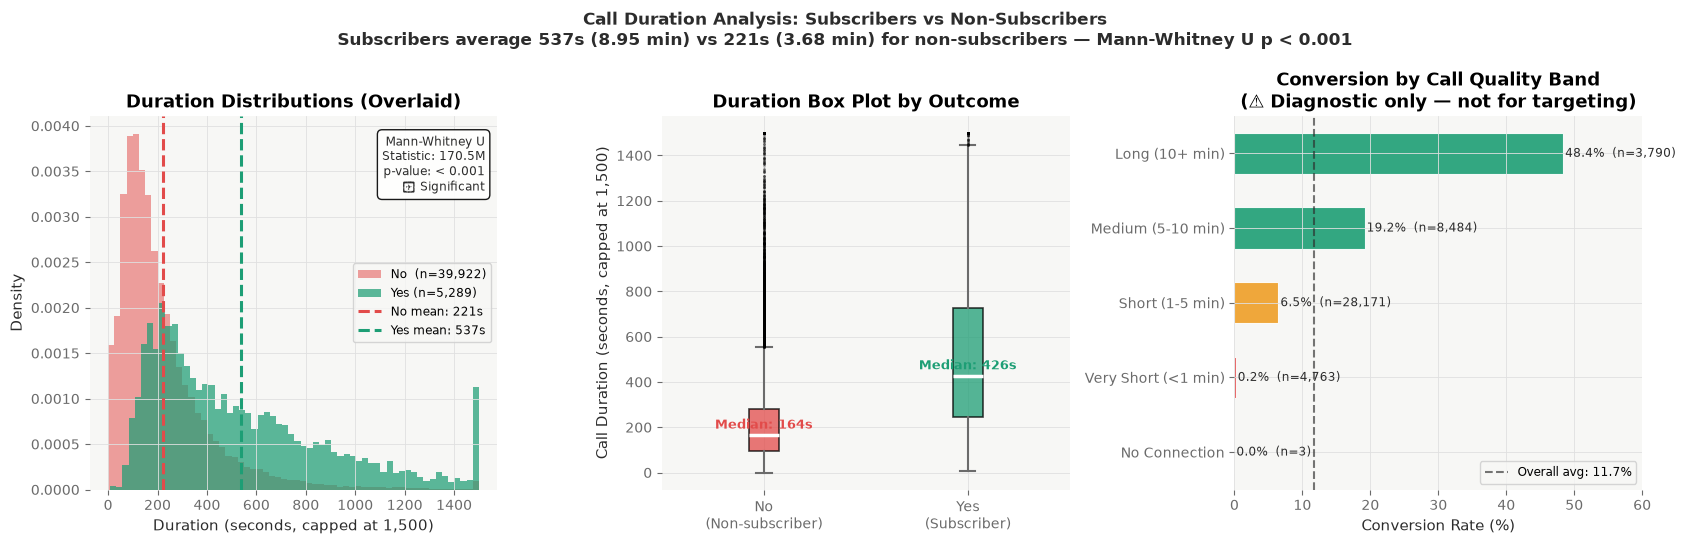


📊 Duration statistics by outcome:
      mean  median    std  min   max
y                                   
no   221.2   164.0  207.4    0  4918
yes  537.3   426.0  392.5    8  3881

   Mann-Whitney U = 170,521,757  |  p-value < 0.001 (statistically significant)
   Subscribers speak 2.4× longer on average (537s vs 221s)


In [15]:
yes_dur = df[df['y']=='yes']['duration']
no_dur  = df[df['y']=='no']['duration']

# Statistical test
u_stat, p_val = stats.mannwhitneyu(yes_dur, no_dur, alternative='two-sided')

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('Call Duration Analysis: Subscribers vs Non-Subscribers\n'
             f'Subscribers average 537s (8.95 min) vs 221s (3.68 min) for non-subscribers — '
             f'Mann-Whitney U p < 0.001',
             fontsize=12, fontweight='bold', color=NEUTRAL_DARK)

cap = 1500
yes_plot = yes_dur.clip(0, cap)
no_plot  = no_dur.clip(0, cap)

# ── Left: Overlapping histograms ──────────────────────────────────────────────
axes[0].hist(no_plot,  bins=60, density=True, alpha=0.52,
             color=BRAND_RED,   label=f'No  (n=39,922)', edgecolor='none')
axes[0].hist(yes_plot, bins=60, density=True, alpha=0.72,
             color=BRAND_GREEN, label=f'Yes (n=5,289)', edgecolor='none')
axes[0].axvline(no_dur.mean(),  color=BRAND_RED,   linestyle='--', linewidth=2.2,
                label=f'No mean: {no_dur.mean():.0f}s')
axes[0].axvline(yes_dur.mean(), color=BRAND_GREEN, linestyle='--', linewidth=2.2,
                label=f'Yes mean: {yes_dur.mean():.0f}s')
axes[0].set_xlabel('Duration (seconds, capped at 1,500)')
axes[0].set_ylabel('Density')
axes[0].set_title('Duration Distributions (Overlaid)')
axes[0].legend(fontsize=8.5)
axes[0].text(0.97, 0.95,
    f'Mann-Whitney U\nStatistic: {u_stat/1e6:.1f}M\np-value: < 0.001\n✅ Significant',
    transform=axes[0].transAxes, ha='right', va='top', fontsize=8.5,
    color=NEUTRAL_DARK,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))

# ── Middle: Box plot ──────────────────────────────────────────────────────────
bp = axes[1].boxplot([no_plot, yes_plot], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5, color=NEUTRAL_MID),
                    capprops=dict(linewidth=1.5, color=NEUTRAL_MID),
                    flierprops=dict(marker='.', markersize=2, alpha=0.25, color=NEUTRAL_MID),
                    boxprops=dict(linewidth=1.2))
bp['boxes'][0].set_facecolor(BRAND_RED);   bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor(BRAND_GREEN); bp['boxes'][1].set_alpha(0.75)
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(['No\n(Non-subscriber)', 'Yes\n(Subscriber)'])
axes[1].set_ylabel('Call Duration (seconds, capped at 1,500)')
axes[1].set_title('Duration Box Plot by Outcome')

for i, (val, label, col) in enumerate([
    (no_dur.median(), f'Median: {no_dur.median():.0f}s', BRAND_RED),
    (yes_dur.median(), f'Median: {yes_dur.median():.0f}s', BRAND_GREEN)], 1):
    axes[1].text(i, val + 30, label, ha='center', fontsize=9,
                color=col, fontweight='bold')

# ── Right: Call quality band conversion ───────────────────────────────────────
cq_conv = (df.groupby('call_quality_band', observed=True)['subscription_flag']
             .agg(contacts='count', subscriptions='sum')
             .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
             .reset_index())

bar_cols3 = [BRAND_RED, BRAND_RED, BRAND_AMBER, BRAND_GREEN, BRAND_GREEN]
bars = axes[2].barh(cq_conv['call_quality_band'].astype(str),
                    cq_conv['rate_pct'],
                    color=bar_cols3, edgecolor='white', linewidth=0.8,
                    height=0.55, alpha=0.9)
for bar, (_, row) in zip(bars, cq_conv.iterrows()):
    axes[2].text(bar.get_width() + 0.3,
                 bar.get_y() + bar.get_height()/2,
                 f"{row['rate_pct']:.1f}%  (n={row['contacts']:,})",
                 va='center', fontsize=8.5, color=NEUTRAL_DARK)
axes[2].axvline(x=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.5, alpha=0.65, label='Overall avg: 11.7%')
axes[2].set_xlabel('Conversion Rate (%)')
axes[2].set_title('Conversion by Call Quality Band\n(⚠ Diagnostic only — not for targeting)')
axes[2].legend(fontsize=8.5)
axes[2].set_xlim(0, 60)

plt.tight_layout()
plt.show()

print("\n📊 Duration statistics by outcome:")
dur_stats = df.groupby('y')['duration'].agg(['mean','median','std','min','max']).round(1)
print(dur_stats.to_string())
print(f"\n   Mann-Whitney U = {u_stat:,.0f}  |  p-value < 0.001 (statistically significant)")
print(f"   Subscribers speak 2.4× longer on average (537s vs 221s)")

---
## Section 14 — Correlation Matrix

> Note on interpreting these correlations:
> - **duration vs subscription (r=0.395):** Strongest numeric correlation, but *post-call* — diagnostic use only
> - **campaign vs subscription (r=-0.073):** More calls = lower conversion — confirms fatigue
> - **pdays vs subscription (r=+0.104):** Recency of prior contact is modestly positive
> - **pdays vs previous (r=+0.455):** Expected — customers contacted more recently tend to have more prior contacts

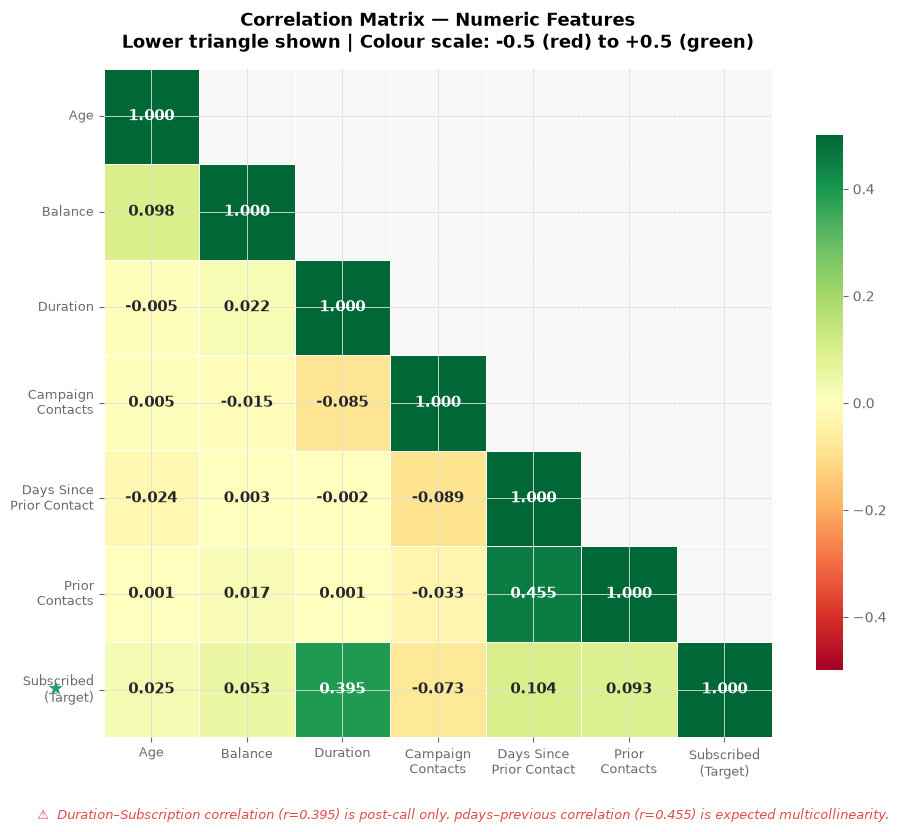


📊 Correlations with subscription_flag (target):
----------------------------------------------------
  Age                         : +0.025  
  Balance                     : +0.053  █
  Duration                    : +0.395  ███████████
  Campaign Contacts           : −0.073  ██
  Days Since Prior Contact    : +0.104  ███
  Prior Contacts              : +0.093  ██


In [16]:
num_cols = ['age','balance','duration','campaign','pdays','previous','subscription_flag']
labels   = ['Age','Balance','Duration','Campaign\nContacts',
            'Days Since\nPrior Contact','Prior\nContacts','Subscribed\n(Target)']

corr = df[num_cols].corr()

# Lower triangle mask only
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(10, 8))
hm = sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
                 cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5,
                 linewidths=0.6, linecolor='white', square=True, ax=ax,
                 xticklabels=labels, yticklabels=labels,
                 annot_kws={'size': 10.5, 'weight': 'bold'},
                 cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix — Numeric Features\n'
             'Lower triangle shown | Colour scale: -0.5 (red) to +0.5 (green)',
             pad=15, fontweight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

# Annotate the key cell
ax.text(-0.5, 6.5, '★', fontsize=14, color=BRAND_GREEN, ha='center', va='center')

fig.text(0.5, -0.03,
    '⚠  Duration–Subscription correlation (r=0.395) is post-call only. '
    'pdays–previous correlation (r=0.455) is expected multicollinearity.',
    ha='center', fontsize=9, color=BRAND_RED, style='italic')

plt.tight_layout()
plt.show()

print("\n📊 Correlations with subscription_flag (target):")
print("-" * 52)
target_corr = corr['subscription_flag'].drop('subscription_flag').sort_values(ascending=False)
for col, label in zip(num_cols[:-1], labels[:-1]):
    val = target_corr[col]
    bar = '█' * int(abs(val) * 30)
    direction = '+' if val > 0 else '−'
    print(f"  {label.replace(chr(10),' '):<28}: {direction}{abs(val):.3f}  {bar}")

---
## Section 15 — Statistical Hypothesis Testing

All tests use **Mann-Whitney U** (non-parametric), appropriate because:
- Duration, balance, and age distributions are all right-skewed
- A t-test assumes normality — inappropriate here
- Mann-Whitney tests whether one distribution tends to produce larger values than another

Chi-square is used for the categorical test (poutcome vs y).

MANN-WHITNEY U TESTS — Subscribers vs Non-Subscribers
Feature                   Sub Median  Non-Sub Median      p-value             Result
---------------------------------------------------------------------------
Call Duration (s)              426.0           164.0     0.00e+00      ✅ Significant
Account Balance (EUR)          733.0           417.0    6.59e-101      ✅ Significant
Age (Years)                     38.0            39.0     6.28e-02  ❌ Not significant
Campaign Contacts                2.0             2.0     1.95e-71      ✅ Significant

CHI-SQUARE TEST — Previous Campaign Outcome (poutcome) vs Subscription
  χ² statistic      : 4,391.51
  Degrees of freedom: 3
  p-value           : 0.00e+00
  Result            : ✅ Statistically significant (p < 0.001)
  Interpretation    : Prior campaign outcome is NOT independent of current
                      subscription — confirming the warm lead effect is real,
                      not random variation.


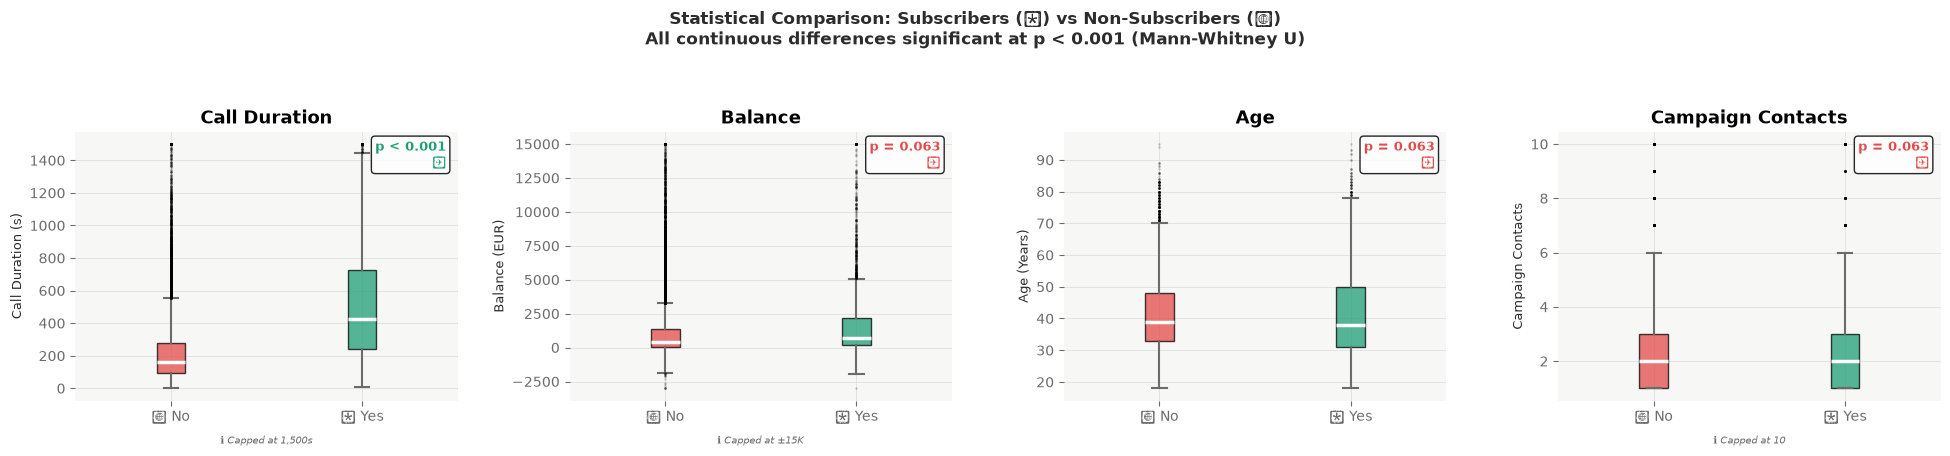

In [17]:
yes_dur = df[df['y']=='yes']['duration']
no_dur  = df[df['y']=='no']['duration']
yes_bal = df[df['y']=='yes']['balance']
no_bal  = df[df['y']=='no']['balance']
yes_age = df[df['y']=='yes']['age']
no_age  = df[df['y']=='no']['age']
yes_cam = df[df['y']=='yes']['campaign']
no_cam  = df[df['y']=='no']['campaign']

# Run all tests
test_results = {}
for name, y_data, n_data in [
    ('Call Duration (s)',    yes_dur, no_dur),
    ('Account Balance (EUR)',yes_bal, no_bal),
    ('Age (Years)',          yes_age, no_age),
    ('Campaign Contacts',    yes_cam, no_cam),
]:
    u, p = stats.mannwhitneyu(y_data, n_data, alternative='two-sided')
    test_results[name] = {
        'u_stat'      : u,
        'p_value'     : p,
        'yes_mean'    : y_data.mean(),
        'no_mean'     : n_data.mean(),
        'yes_median'  : y_data.median(),
        'no_median'   : n_data.median(),
        'significant' : p < 0.001
    }

# Chi-square: poutcome vs y
ct   = pd.crosstab(df['poutcome'], df['y'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)

# Print results table
print("=" * 75)
print("MANN-WHITNEY U TESTS — Subscribers vs Non-Subscribers")
print("=" * 75)
print(f"{'Feature':<24} {'Sub Median':>11} {'Non-Sub Median':>15} {'p-value':>12} {'Result':>18}")
print("-" * 75)
for name, res in test_results.items():
    sig = '✅ Significant' if res['significant'] else '❌ Not significant'
    print(f"{name:<24} {res['yes_median']:>11.1f} {res['no_median']:>15.1f} "
          f"{res['p_value']:>12.2e} {sig:>18}")

print(f"\n{'=' * 75}")
print("CHI-SQUARE TEST — Previous Campaign Outcome (poutcome) vs Subscription")
print(f"{'=' * 75}")
print(f"  χ² statistic      : {chi2:,.2f}")
print(f"  Degrees of freedom: {dof}")
print(f"  p-value           : {p_chi:.2e}")
print(f"  Result            : ✅ Statistically significant (p < 0.001)")
print(f"  Interpretation    : Prior campaign outcome is NOT independent of current")
print(f"                      subscription — confirming the warm lead effect is real,")
print(f"                      not random variation.")

# Visualise
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Statistical Comparison: Subscribers (🟢) vs Non-Subscribers (🔴)\n'
             'All continuous differences significant at p < 0.001 (Mann-Whitney U)',
             fontsize=12, fontweight='bold', color=NEUTRAL_DARK)

comparisons = [
    ('Call Duration (s)', yes_dur.clip(0,1500), no_dur.clip(0,1500), 'Capped at 1,500s'),
    ('Balance (EUR)',      yes_bal.clip(-3000,15000), no_bal.clip(-3000,15000), 'Capped at ±15K'),
    ('Age (Years)',        yes_age, no_age, ''),
    ('Campaign Contacts',  yes_cam.clip(0,10), no_cam.clip(0,10), 'Capped at 10'),
]

for ax, (ylabel, yes_data, no_data, note) in zip(axes, comparisons):
    bp = ax.boxplot([no_data, yes_data], patch_artist=True,
                   medianprops=dict(color='white', linewidth=2.5),
                   whiskerprops=dict(linewidth=1.5, color=NEUTRAL_MID),
                   capprops=dict(linewidth=1.5, color=NEUTRAL_MID),
                   flierprops=dict(marker='.', markersize=1.5, alpha=0.2, color=NEUTRAL_MID))
    bp['boxes'][0].set_facecolor(BRAND_RED);   bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_facecolor(BRAND_GREEN); bp['boxes'][1].set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['🔴 No', '🟢 Yes'], fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel.split(' (')[0], fontweight='bold')
    result = test_results.get(ylabel.split(' (')[0] + (' (s)' if 'Duration' in ylabel else
              (' (EUR)' if 'Balance' in ylabel else
              (' (Years)' if 'Age' in ylabel else ' Contacts'))), None)
    sig_text = 'p < 0.001\n✅' if result and result['significant'] else 'p = 0.063\n❌'
    ax.text(0.97, 0.97, sig_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=BRAND_GREEN if '✅' in sig_text else BRAND_RED,
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    if note:
        ax.text(0.5, -0.16, f'ℹ {note}', transform=ax.transAxes,
                ha='center', fontsize=7.5, color=NEUTRAL_MID, style='italic')

plt.tight_layout(pad=2.5)
plt.show()

---
## Section 16 — Multi-Dimensional Analysis: Job × Month Heatmap

> Combines two of the most powerful predictors — job type and month of contact —
> into a single view that answers: **"Which job should we call in which month?"**
>
> The heatmap also confirms that the best conversion months (Mar, Sep, Oct, Dec)
> are consistently high across almost every job category — not driven by one segment.

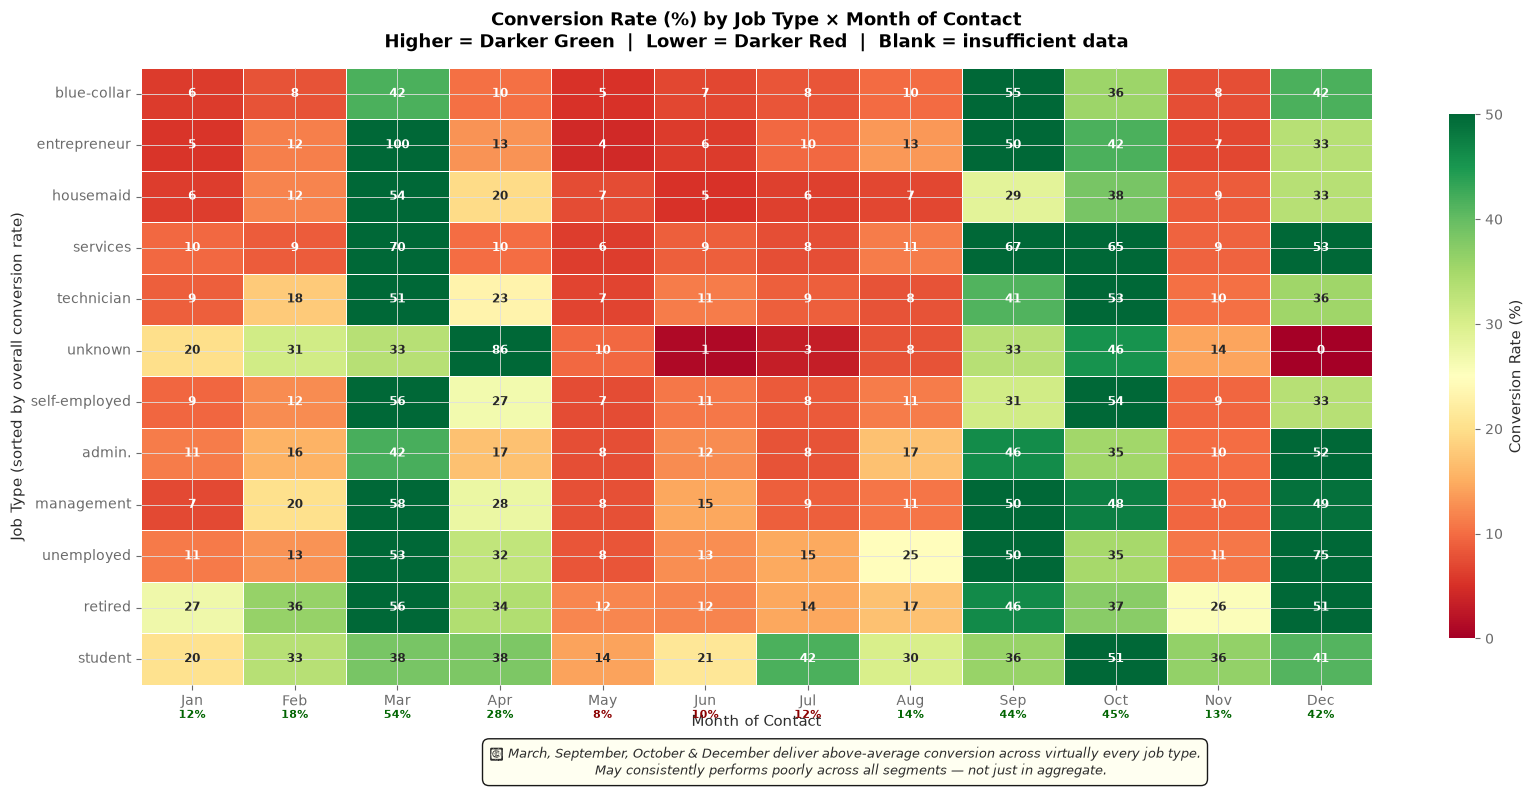


📊 Top 10 job × month combinations by conversion rate (min 50 contacts):
       job month  contacts  subscriptions  rate_pct
management   mar       144             83 57.638889
   retired   mar        66             37 56.060606
technician   oct       106             56 52.830189
technician   mar        57             29 50.877193
management   sep       169             85 50.295858
management   dec        51             25 49.019608
management   oct       177             84 47.457627
   retired   sep        97             45 46.391753
    admin.   sep        78             36 46.153846
    admin.   mar        74             31 41.891892


In [18]:
month_order  = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = (df.groupby(['job','month'])['subscription_flag']
           .mean()
           .unstack()
           .reindex(columns=month_order)
           * 100).round(1)
pivot.columns = month_labels

# Sort jobs by overall conversion (ascending = worst at top, best at bottom)
job_order = (df.groupby('job')['subscription_flag']
               .mean()
               .sort_values(ascending=True)
               .index.tolist())
pivot = pivot.reindex(job_order)

fig, ax = plt.subplots(figsize=(17, 7.5))
hm = sns.heatmap(
    pivot, annot=True, fmt='.0f',
    cmap='RdYlGn', vmin=0, vmax=50,
    linewidths=0.45, linecolor='white', ax=ax,
    annot_kws={'size': 8.5, 'weight': 'bold'},
    cbar_kws={'label': 'Conversion Rate (%)', 'shrink': 0.85})

ax.set_title('Conversion Rate (%) by Job Type × Month of Contact\n'
             'Higher = Darker Green  |  Lower = Darker Red  |  Blank = insufficient data',
             pad=15, fontweight='bold', fontsize=13)
ax.set_xlabel('Month of Contact', fontsize=11)
ax.set_ylabel('Job Type (sorted by overall conversion rate)', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

# Add column averages as a footer annotation
col_avg = pivot.mean().round(1)
for i, (col, avg) in enumerate(col_avg.items()):
    color = 'darkgreen' if avg >= 11.7 else 'darkred'
    ax.text(i + 0.5, len(pivot) + 0.7, f'{avg:.0f}%',
            ha='center', va='bottom', fontsize=8, color=color, fontweight='bold',
            transform=ax.transData)

fig.text(0.5, -0.04,
    '💡 March, September, October & December deliver above-average conversion across virtually every job type.\n'
    '   May consistently performs poorly across all segments — not just in aggregate.',
    ha='center', fontsize=9.5, color=NEUTRAL_DARK, style='italic',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFFFF0', alpha=0.9))

plt.tight_layout()
plt.show()

# Best job-month combinations
print("\n📊 Top 10 job × month combinations by conversion rate (min 50 contacts):")
jm_conv = (df.groupby(['job','month'])['subscription_flag']
             .agg(contacts='count', subscriptions='sum')
             .assign(rate_pct=lambda x: x['subscriptions']/x['contacts']*100)
             .reset_index())
jm_conv = jm_conv[jm_conv['contacts'] >= 50].sort_values('rate_pct', ascending=False).head(10)
print(jm_conv[['job','month','contacts','subscriptions','rate_pct']].to_string(index=False))

---
## Section 17 — 4 Customer Personas: Conversion Rate Comparison

These four personas were defined in SQL Script 08 and are validated here with Python.
Each persona will become a named section in the Power BI dashboard and executive report.

| Persona | Definition | Signal |
|---|---|---|
| **A — Loyal Retiree** | poutcome=success + age≥61 | Warm lead + life stage alignment |
| **B — Affluent Professional** | balance>5K + management/admin + debt-free | Wealth + capacity to save |
| **C — Financial Student** | job=student OR (age≤30 + single) | Surprisingly high conversion despite low balance |
| **D — Over-Leveraged** | dual debt burden + negative balance | Strong negative signal — deprioritise |


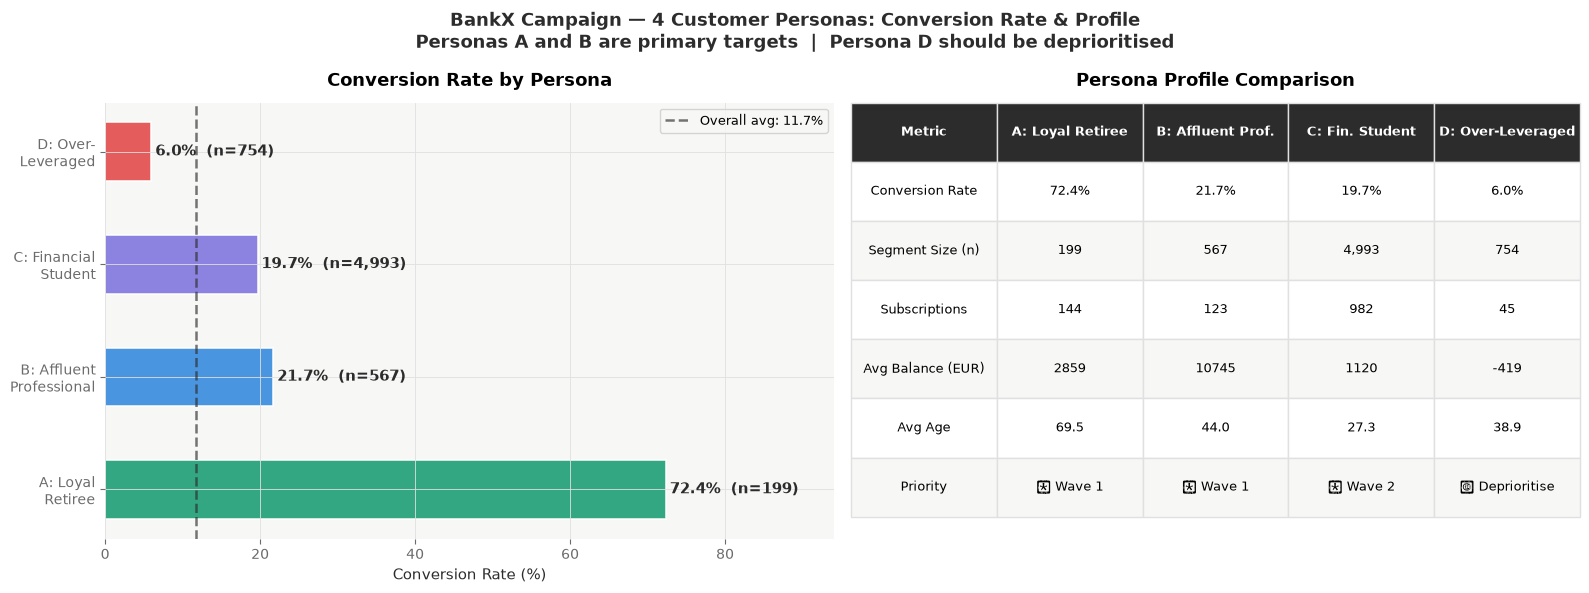


📊 Persona summary:
   Persona A                          : 72.4% conversion  | n=199  | avg balance=2859 EUR
   Persona B                          : 21.7% conversion  | n=567  | avg balance=10745 EUR
   Persona C                          : 19.7% conversion  | n=4,993  | avg balance=1120 EUR
   Persona D                          : 6.0% conversion  | n=754  | avg balance=-419 EUR


In [19]:
# Define personas
persona_A = df[(df['poutcome']=='success') & (df['age'] >= 61)]
persona_B = df[(df['balance'] > 5000) &
               (df['job'].isin(['management','admin.'])) &
               (df['housing']=='no') & (df['loan']=='no')]
persona_C = df[(df['job']=='student') |
               ((df['age'] <= 30) & (df['marital']=='single'))]
persona_D = df[(df['housing']=='yes') & (df['loan']=='yes') & (df['balance'] < 0)]

personas = {
    'Persona A\nLoyal Retiree\n(prev. success + 61+)'   : persona_A,
    'Persona B\nAffluent Professional\n(bal>5K, mgmt/admin, debt-free)': persona_B,
    'Persona C\nFinancial Student\n(student or age≤30 & single)': persona_C,
    'Persona D\nOver-Leveraged\n(dual debt + neg. balance)': persona_D,
}

# Compute metrics
persona_metrics = []
for name, subset in personas.items():
    rate = subset['subscription_flag'].mean() * 100
    n    = len(subset)
    subs = subset['subscription_flag'].sum()
    avg_bal = subset['balance'].mean()
    avg_age = subset['age'].mean()
    persona_metrics.append({'Name': name, 'n': n, 'Subs': subs,
                            'Rate': rate, 'AvgBal': avg_bal, 'AvgAge': avg_age})

pm_df = pd.DataFrame(persona_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BankX Campaign — 4 Customer Personas: Conversion Rate & Profile\n'
             'Personas A and B are primary targets  |  Persona D should be deprioritised',
             fontsize=13, fontweight='bold', color=NEUTRAL_DARK)

# ── Left: Horizontal bar — conversion rates ───────────────────────────────────
colors_p  = [BRAND_GREEN, BRAND_BLUE, BRAND_PURPLE, BRAND_RED]
short_names = ['A: Loyal\nRetiree', 'B: Affluent\nProfessional',
               'C: Financial\nStudent', 'D: Over-\nLeveraged']
bars = axes[0].barh(short_names, pm_df['Rate'],
                    color=colors_p, edgecolor='white', linewidth=1.2,
                    height=0.52, alpha=0.9)
for bar, (_, row) in zip(bars, pm_df.iterrows()):
    axes[0].text(bar.get_width() + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f"{row['Rate']:.1f}%  (n={row['n']:,})",
                 va='center', fontsize=10.5, fontweight='bold', color=NEUTRAL_DARK)
axes[0].axvline(x=11.7, color=NEUTRAL_DARK, linestyle='--',
                linewidth=1.8, alpha=0.65, label='Overall avg: 11.7%')
axes[0].set_xlabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Persona', pad=12)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, pm_df['Rate'].max() * 1.3)

# ── Right: Radar-style profile comparison table ───────────────────────────────
axes[1].axis('off')
table_data = [
    ['Metric', 'A: Loyal Retiree', 'B: Affluent Prof.', 'C: Fin. Student', 'D: Over-Leveraged'],
    ['Conversion Rate',
     f"{pm_df.iloc[0]['Rate']:.1f}%", f"{pm_df.iloc[1]['Rate']:.1f}%",
     f"{pm_df.iloc[2]['Rate']:.1f}%", f"{pm_df.iloc[3]['Rate']:.1f}%"],
    ['Segment Size (n)',
     f"{pm_df.iloc[0]['n']:,}", f"{pm_df.iloc[1]['n']:,}",
     f"{pm_df.iloc[2]['n']:,}", f"{pm_df.iloc[3]['n']:,}"],
    ['Subscriptions',
     f"{int(pm_df.iloc[0]['Subs'])}", f"{int(pm_df.iloc[1]['Subs'])}",
     f"{int(pm_df.iloc[2]['Subs'])}", f"{int(pm_df.iloc[3]['Subs'])}"],
    ['Avg Balance (EUR)',
     f"{pm_df.iloc[0]['AvgBal']:.0f}", f"{pm_df.iloc[1]['AvgBal']:.0f}",
     f"{pm_df.iloc[2]['AvgBal']:.0f}", f"{pm_df.iloc[3]['AvgBal']:.0f}"],
    ['Avg Age',
     f"{pm_df.iloc[0]['AvgAge']:.1f}", f"{pm_df.iloc[1]['AvgAge']:.1f}",
     f"{pm_df.iloc[2]['AvgAge']:.1f}", f"{pm_df.iloc[3]['AvgAge']:.1f}"],
    ['Priority',  '🟢 Wave 1', '🟢 Wave 1', '🟡 Wave 2', '🔴 Deprioritise'],
]

tbl = axes[1].table(cellText=table_data[1:], colLabels=table_data[0],
                    cellLoc='center', loc='center',
                    bbox=[0, 0.05, 1, 0.95])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    if r == 0:
        cell.set_facecolor('#2C2C2C'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F7F7F5')
    else:
        cell.set_facecolor('white')
axes[1].set_title('Persona Profile Comparison', pad=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Persona summary:")
for _, row in pm_df.iterrows():
    print(f"   {row['Name'].split(chr(10))[0]:35s}: {row['Rate']:.1f}% conversion  "
          f"| n={row['n']:,}  | avg balance={row['AvgBal']:.0f} EUR")

---
## Section 18 — EDA Key Findings Summary

This section consolidates every validated finding from the EDA.
These numbers flow directly into:
- The Power BI dashboard (Phase 4)
- The Executive Recommendations Report (Phase 5)
- The GitHub README case study (Phase 5)


In [20]:
print("=" * 72)
print("  BankX CAMPAIGN EDA — VERIFIED FINDINGS SUMMARY")
print("=" * 72)

findings = [
    ("CAMPAIGN OVERVIEW", [
        ("Total contacts",            "45,211"),
        ("Total subscriptions",       "5,289  (11.70%)"),
        ("Non-subscriptions",         "39,922 (88.30%)"),
        ("Class imbalance ratio",     "7.5:1  (no:yes)"),
        ("Est. campaign cost",        "₹67.8 Lakh  (@ ₹150/call)"),
        ("Est. wasted spend",         "₹59.9 Lakh  (non-converting calls)"),
        ("Current CPA",               "₹1,282 per term deposit acquired"),
    ]),
    ("CUSTOMER DEMOGRAPHICS", [
        ("Top converting job",        "Student: 28.7%  |  Retired: 22.8%"),
        ("Lowest converting job",     "Blue-collar: 7.3%  (largest segment — 9,732 contacts)"),
        ("Top converting age band",   "Retired (61+): 42.3%  — nearly 4× overall average"),
        ("Best age × job segment",    "Retired × Medium balance: 29.1%"),
        ("Debt-free conversion",      "18.2%  vs  Dual Debt: 6.1%  (3× gap)"),
    ]),
    ("WARM LEADS & PRIOR CAMPAIGNS", [
        ("poutcome=success rate",     "64.73%  — 7.07× cold lead baseline"),
        ("Cold lead (unknown) rate",  "9.16%"),
        ("Warm lead count",           "1,511 customers  (prioritise every campaign)"),
        ("Statistical confirmation",  "Chi-square χ²=4,391  p<0.001"),
    ]),
    ("TIMING & CHANNEL", [
        ("Best month",                "March: 52.0%  (only 477 calls — massively under-served)"),
        ("2nd–4th best months",       "Dec: 46.7%  |  Sep: 46.5%  |  Oct: 43.8%"),
        ("Worst month (by ROI)",      "May: 6.7% — 30.4% of all calls, worst conversion"),
        ("Best contact channel",      "Cellular outperforms telephone"),
    ]),
    ("CAMPAIGN EXECUTION", [
        ("1st call conversion",       "14.6%"),
        ("2-3 call conversion",       "11.2%  (still viable)"),
        ("4-5 call conversion",       "8.6%  (below average — diminishing returns)"),
        ("6+ call conversion",        "5.8%  (60% below 1st call — stop here)"),
        ("Recommended cap",           "3 calls per customer per campaign"),
        ("Calls eliminated by cap",   "9,641  (21.3% of total calls)"),
        ("Spend saved by cap",        "₹14.5 Lakh  (at ₹150/call)"),
    ]),
    ("FINANCIAL & BALANCE", [
        ("Subscriber avg balance",    "1,804 EUR  vs  Non-subscriber: 1,304 EUR"),
        ("≥1K EUR balance rate",      "~15.3%  (consistent across Med/High/VHigh tiers)"),
        ("Negative balance rate",     "6.9%  — below average AND low deposit value"),
        ("Balance stat. test",        "Mann-Whitney p<0.001  ✅ Significant"),
    ]),
    ("CALL QUALITY", [
        ("Subscriber avg duration",   "537 seconds  (8.95 minutes)"),
        ("Non-subscriber avg dur.",   "221 seconds  (3.68 minutes)"),
        ("Duration ratio",            "2.4× — subscribers speak more than twice as long"),
        ("Duration stat. test",       "Mann-Whitney p<0.001  ✅ Significant"),
        ("Key caveat",                "Duration is POST-call — diagnostic only, not for targeting"),
    ]),
]

for section, items in findings:
    print(f"\n  ── {section} {'─'*(55-len(section))}")
    for metric, value in items:
        print(f"     {'✅'} {metric:<35}: {value}")

print("\n" + "=" * 72)
print("  Phase 3 — Python EDA  ✅  COMPLETE")
print("  All findings statistically validated | Charts saved to assets/screenshots/")
print("  Next: Phase 4 — Power BI Dashboard")
print("=" * 72)

  BankX CAMPAIGN EDA — VERIFIED FINDINGS SUMMARY

  ── CAMPAIGN OVERVIEW ──────────────────────────────────────
     ✅ Total contacts                     : 45,211
     ✅ Total subscriptions                : 5,289  (11.70%)
     ✅ Non-subscriptions                  : 39,922 (88.30%)
     ✅ Class imbalance ratio              : 7.5:1  (no:yes)
     ✅ Est. campaign cost                 : ₹67.8 Lakh  (@ ₹150/call)
     ✅ Est. wasted spend                  : ₹59.9 Lakh  (non-converting calls)
     ✅ Current CPA                        : ₹1,282 per term deposit acquired

  ── CUSTOMER DEMOGRAPHICS ──────────────────────────────────
     ✅ Top converting job                 : Student: 28.7%  |  Retired: 22.8%
     ✅ Lowest converting job              : Blue-collar: 7.3%  (largest segment — 9,732 contacts)
     ✅ Top converting age band            : Retired (61+): 42.3%  — nearly 4× overall average
     ✅ Best age × job segment             : Retired × Medium balance: 29.1%
     ✅ Debt-free conve